# Truth Lepton Kinematics — Summary Across Signal Phase Space

This notebook is a distillation of the larger `lepton_kinematics_DPorLabFrame.ipynb` study, run over the **full 3×3 signal phase space**:

- Bound-state masses: **M_BS ∈ {100, 500, 1000} GeV**
- Dark photon masses: **M_Zd ∈ {0.25, 1.2, 5.0} GeV**

For 1D distributions all 9 samples are overlaid (color = M_BS, line style = M_Zd). For 2D distributions and polarization fits, a 3×3 grid of subplots is used so each sample is visible separately.

The per-sample processor outputs are cached as `.coffea` files alongside this notebook — re-running the cell will skip samples whose output already exists. Delete a file to force re-processing.


In [1]:
# python
import sys
import os
import awkward as ak
import numpy as np
import coffea
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import matplotlib.pyplot as plt
import mplhep as hep
from scipy import optimize as opt
import importlib

# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)

from sidm.tools import sidm_processor, llpnanoaodschema, utilities, scaleout
importlib.reload(sidm_processor)
importlib.reload(llpnanoaodschema)
importlib.reload(utilities)

utilities.set_plot_style()
# Bump dpi above the default (set_plot_style sets dpi=50, too low for multi-panel grids)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

In [2]:
# Sample phase space (3x3): M_BS x M_Zd
SAMPLE_GRID = {
    100:  {0.25: "2Mu2E_100GeV_0p25GeV_2p0mm",
           1.2:  "2Mu2E_100GeV_1p2GeV_9p6mm",
           5.0:  "2Mu2E_100GeV_5p0GeV_40p0mm"},
    500:  {0.25: "2Mu2E_500GeV_0p25GeV_0p4mm",
           1.2:  "2Mu2E_500GeV_1p2GeV_1p9mm",
           5.0:  "2Mu2E_500GeV_5p0GeV_8p0mm"},
    1000: {0.25: "2Mu2E_1000GeV_0p25GeV_0p2mm",
           1.2:  "2Mu2E_1000GeV_1p2GeV_0p96mm",
           5.0:  "2Mu2E_1000GeV_5p0GeV_4p0mm"},
}
BS_MASSES = [100, 500, 1000]
ZD_MASSES = [0.25, 1.2, 5.0]
SAMPLES = [SAMPLE_GRID[bs][zd] for bs in BS_MASSES for zd in ZD_MASSES]

# Style: color = M_BS, linestyle = M_Zd
BS_COLORS     = {100: "tab:blue", 500: "tab:green", 1000: "tab:red"}
ZD_LINESTYLES = {0.25: ":", 1.2: "--", 5.0: "-"}

def sample_label(bs, zd):
    return rf"$M_{{BS}}={bs}$, $M_{{Z_d}}={zd}$ GeV"

# Processor config (same as lepton_kinematics_summary.ipynb)
MAX_FILES = -1   # full statistics
CHANNELS  = ["gen_leptons_final", "gen_leptons_born",]
HISTS     = ["genBS_genA_kinematics",]

In [3]:
# Run-or-load loop with per-sample .coffea caching
fileset = utilities.make_fileset(SAMPLES, "llpNanoAOD_v2", location_cfg="signal_2mu2e_v10.yaml", max_files=MAX_FILES)

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)
p = sidm_processor.SidmProcessor(CHANNELS, HISTS, unweighted_hist=True, verbose=False)

out = {}
for sample in SAMPLES:
    cache_path = f"simplified_{sample}.coffea"
    if os.path.exists(cache_path):
        print(f"[cache] loading {sample}")
        cached = coffea.util.load(cache_path)
        out[sample] = cached["out"][sample]
    else:
        print(f"[run]   processing {sample}")
        fs = {sample: fileset[sample]}
        output = runner.run(fs, treename="Events", processor_instance=p)
        out[sample] = output["out"][sample]
        coffea.util.save(output, cache_path)
print("Done.")

[cache] loading 2Mu2E_100GeV_0p25GeV_2p0mm
[cache] loading 2Mu2E_100GeV_1p2GeV_9p6mm
[cache] loading 2Mu2E_100GeV_5p0GeV_40p0mm
[cache] loading 2Mu2E_500GeV_0p25GeV_0p4mm
[cache] loading 2Mu2E_500GeV_1p2GeV_1p9mm
[cache] loading 2Mu2E_500GeV_5p0GeV_8p0mm
[cache] loading 2Mu2E_1000GeV_0p25GeV_0p2mm
[cache] loading 2Mu2E_1000GeV_1p2GeV_0p96mm
[cache] loading 2Mu2E_1000GeV_5p0GeV_4p0mm
Done.


In [4]:
# Plot helpers
from matplotlib.lines import Line2D

def add_compact_legend(ax, loc_color="upper right", loc_style="upper left", fontsize=12):
    """Two small legends: color = BS mass, linestyle = Zd mass."""
    color_handles = [Line2D([0], [0], color=BS_COLORS[bs], lw=2.5,
                            label=rf"$M_{{BS}}={bs}$ GeV") for bs in BS_MASSES]
    style_handles = [Line2D([0], [0], color="gray", linestyle=ZD_LINESTYLES[zd], lw=2.5,
                            label=rf"$M_{{Z_d}}={zd}$ GeV") for zd in ZD_MASSES]
    leg1 = ax.legend(handles=color_handles, loc=loc_color, fontsize=fontsize,
                     frameon=True, title="BS mass", title_fontsize=fontsize)
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc=loc_style, fontsize=fontsize,
              frameon=True, title=r"$Z_d$ mass", title_fontsize=fontsize)

def overlay_1d(hist_name, channel, ax=None, density=True, xlabel=None, ylabel=None,
               title=None, add_legend=True, cms_label=True, legend_fontsize=12, **plot_kwargs):
    """Overlay a 1D histogram for all 9 samples (color=BS, linestyle=Zd).

    Note: titles are placed inside the axes (top-center) to avoid clashing with
    the mplhep CMS label, which occupies the same y-position above the axes.
    """
    if ax is None:
        ax = plt.gca()
    for bs in BS_MASSES:
        for zd in ZD_MASSES:
            sample = SAMPLE_GRID[bs][zd]
            h = out[sample]["hists"][hist_name][channel, :]
            hep.histplot(h, ax=ax,
                         color=BS_COLORS[bs],
                         linestyle=ZD_LINESTYLES[zd],
                         density=density, **plot_kwargs)
    if cms_label:
        hep.cms.label(ax=ax)
    if xlabel: ax.set_xlabel(xlabel, fontsize=14)
    if ylabel: ax.set_ylabel(ylabel, fontsize=14)
    if title:
        # Place title inside the axes top-center to avoid clashing with CMS label.
        ax.text(0.5, 0.93, title, transform=ax.transAxes, ha="center", va="top",
                fontsize=14, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                          edgecolor="lightgray", alpha=0.85))
    if add_legend: add_compact_legend(ax, fontsize=legend_fontsize)
    return ax

## 1 — Decay topology and lepton statuses

How many BS / Zd / leptons exist per event, and how often do leptons stay status=23 (born, direct daughter of Zd) vs cascade down to status=1 (final state after FSR)?


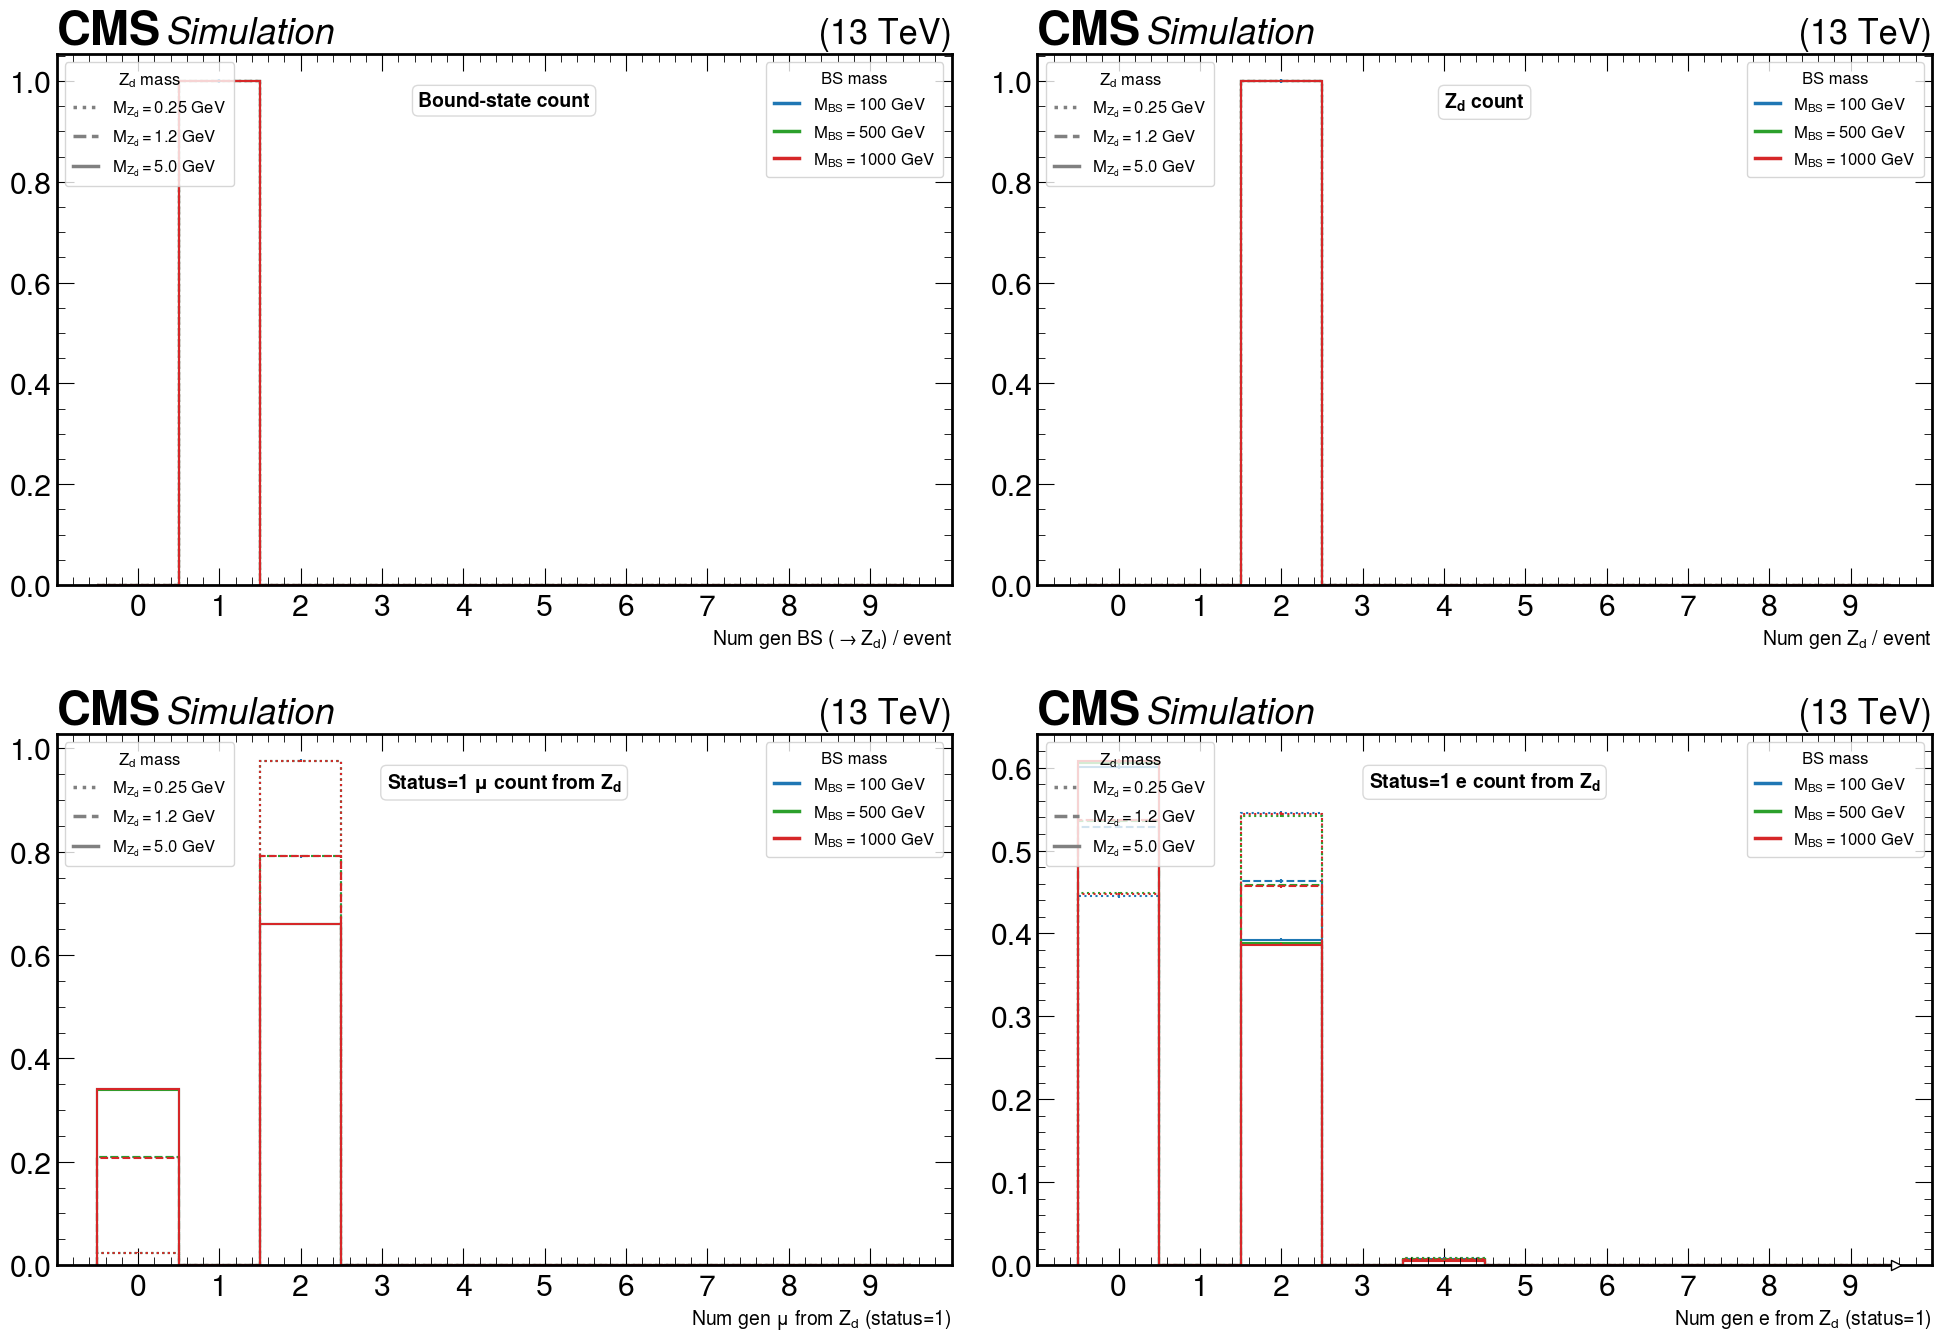

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

ax = axes[0,0]
overlay_1d("genBS_n", CHANNELS[0], ax=ax, density=True,
           xlabel=r"Num gen BS ($\to Z_d$) / event", title="Bound-state count")

ax = axes[0,1]
overlay_1d("genA_n", CHANNELS[0], ax=ax, density=True,
           xlabel=r"Num gen $Z_d$ / event", title=r"$Z_d$ count")

ax = axes[1,0]
overlay_1d("genMus_fromA_n", CHANNELS[0], ax=ax, density=True,
           xlabel=r"Num gen $\mu$ from $Z_d$ (status=1)", title=r"Status=1 $\mu$ count from $Z_d$")

ax = axes[1,1]
overlay_1d("genEs_fromA_n", CHANNELS[0], ax=ax, density=True,
           xlabel=r"Num gen $e$ from $Z_d$ (status=1)", title=r"Status=1 $e$ count from $Z_d$")

plt.tight_layout(); plt.show()

**Observations**

- **Topology confirmed:** every event has exactly **1 BS** and **2 Zd**, across the full phase space (top row). The chain BS → 2 Zd, one Zd → μμ, one Zd → ee is verified at gen level.
- **FSR is the dominant source of variation in the bottom plots.** `genMus_fromA_n` / `genEs_fromA_n` count leptons whose **direct gen-record parent is the Zd**. A status=1 lepton with parent==Zd means *no FSR happened* on that side; if FSR did occur, the status=1 lepton's parent is another lepton (not the Zd), so it doesn't enter this count — that event ends up in the "0" bin.
- **Electrons radiate about twice as often as muons.** For muons the distribution is sharply peaked at 2 (most events: neither muon radiated). For electrons the populations at 0 and 2 are roughly comparable (about half the events: both electrons cascaded through FSR before reaching status=1). This is a direct consequence of $m_e \ll m_\mu$: the lighter the lepton, the easier it is to emit a soft photon.
- **Practical consequence:** the `gen_leptons_final` (status=1) channel paired with `fromPid(., 32)` discards roughly *half* the dielectron statistics and roughly *one quarter* of the dimuon statistics. Analyses that need direct-Zd lepton kinematics should either include the FSR cascade in their object definition or fall back to the status=23 (`gen_leptons_born`) channel.


## 2 — Bound-state kinematics

The BS is the parent of the two Zd. Comparing the gen-record BS (`genBSs_toA`) with the sum of the two daughter Zd (`genBS_from_genAs`) is a closure check on the simulation chain.


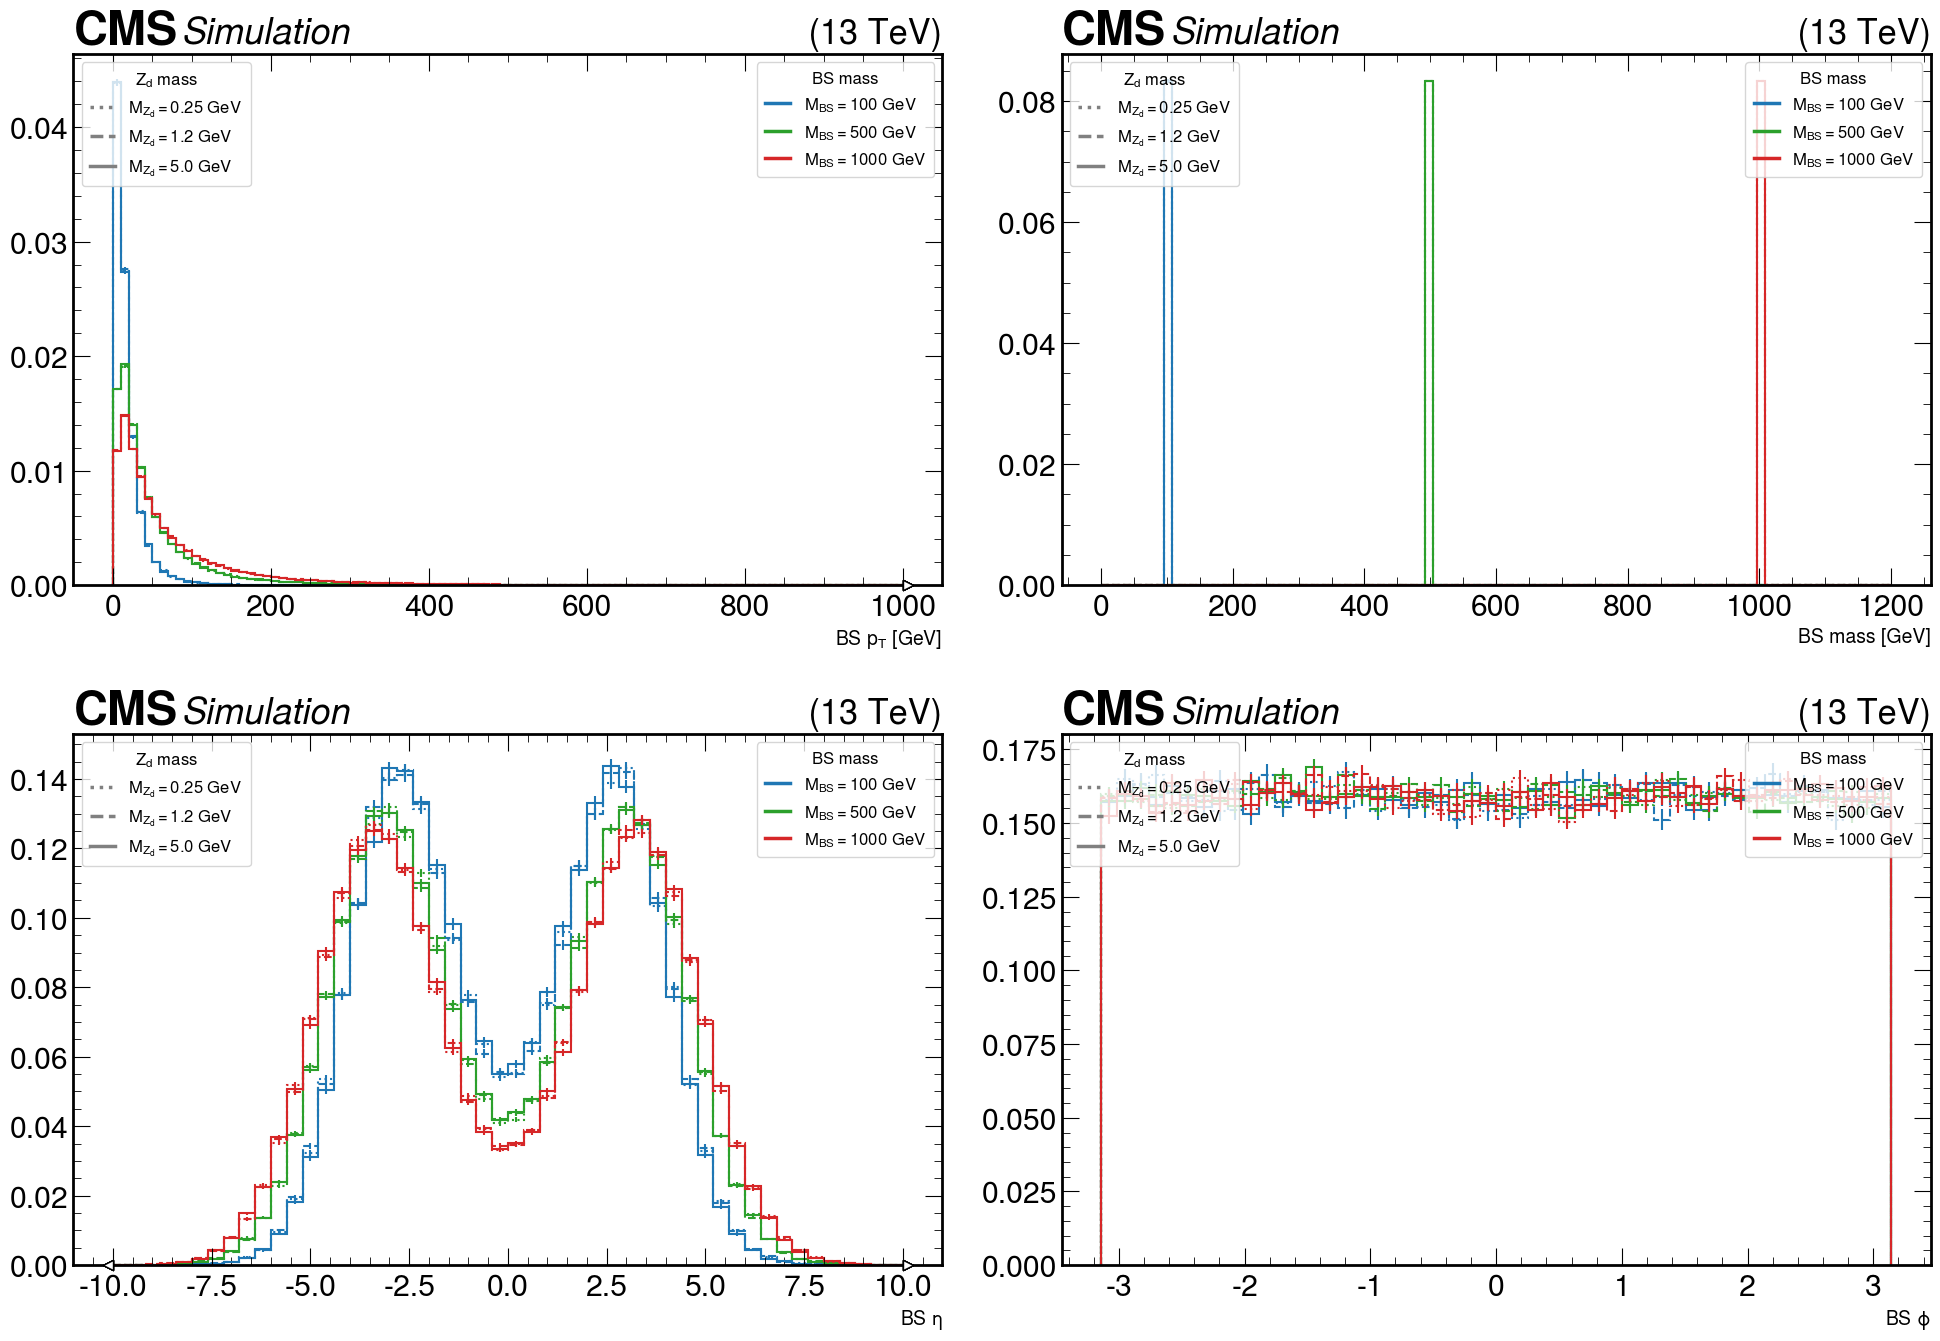

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
overlay_1d("genBS_pt",   CHANNELS[0], ax=axes[0,0], density=True, xlabel=r"BS $p_T$ [GeV]")
overlay_1d("genBS_mass", CHANNELS[0], ax=axes[0,1], density=True, xlabel=r"BS mass [GeV]")
overlay_1d("genBS_eta",  CHANNELS[0], ax=axes[1,0], density=True, xlabel=r"BS $\eta$")
overlay_1d("genBS_phi",  CHANNELS[0], ax=axes[1,1], density=True, xlabel=r"BS $\phi$")
plt.tight_layout(); plt.show()

**Observations**

- **BS mass (top-right):** sharp delta-functions at exactly 100, 500, 1000 GeV — clean gen-level record.
- **BS $p_T$ (top-left):** a falling spectrum in all samples; the lightest BS extends to slightly higher $p_T$ relative to its mass. Production cross section is dominated by the lowest-$p_T$ region for every sample.
- **BS $\eta$ (bottom-left):** the most informative panel. All distributions are bimodal with peaks around $|\eta| \approx 3$, but the **dip at $\eta = 0$ becomes dramatically deeper as $M_{BS}$ grows.** This is standard hadroproduction phenomenology — producing a heavier final state requires higher-$x$ partons, which gives a larger longitudinal boost to the BS. The $M_{Z_d}$ line-style has essentially no effect here, because the BS kinematics are fixed *before* it decays.
- **BS $\phi$ (bottom-right):** flat, as required by azimuthal symmetry of $pp$ collisions. ✓
- **Closure check:** the histograms `genBSs_toA` and `genBS_from_genAs` (sum of the two daughter Zd 4-vectors) are *both filled* by the processor; they overlay perfectly in the per-sample views from `lepton_kinematics_summary.ipynb`, confirming the gen mother/daughter graph is self-consistent.


## 3 — Dark photon kinematics

The Zd $p_T$ peak should scale as $\sim M_{BS}/2$; the Lorentz factor $\gamma = E/M_{Z_d}$ tells us how relativistic the Zd is — this drives lepton-jet collimation.


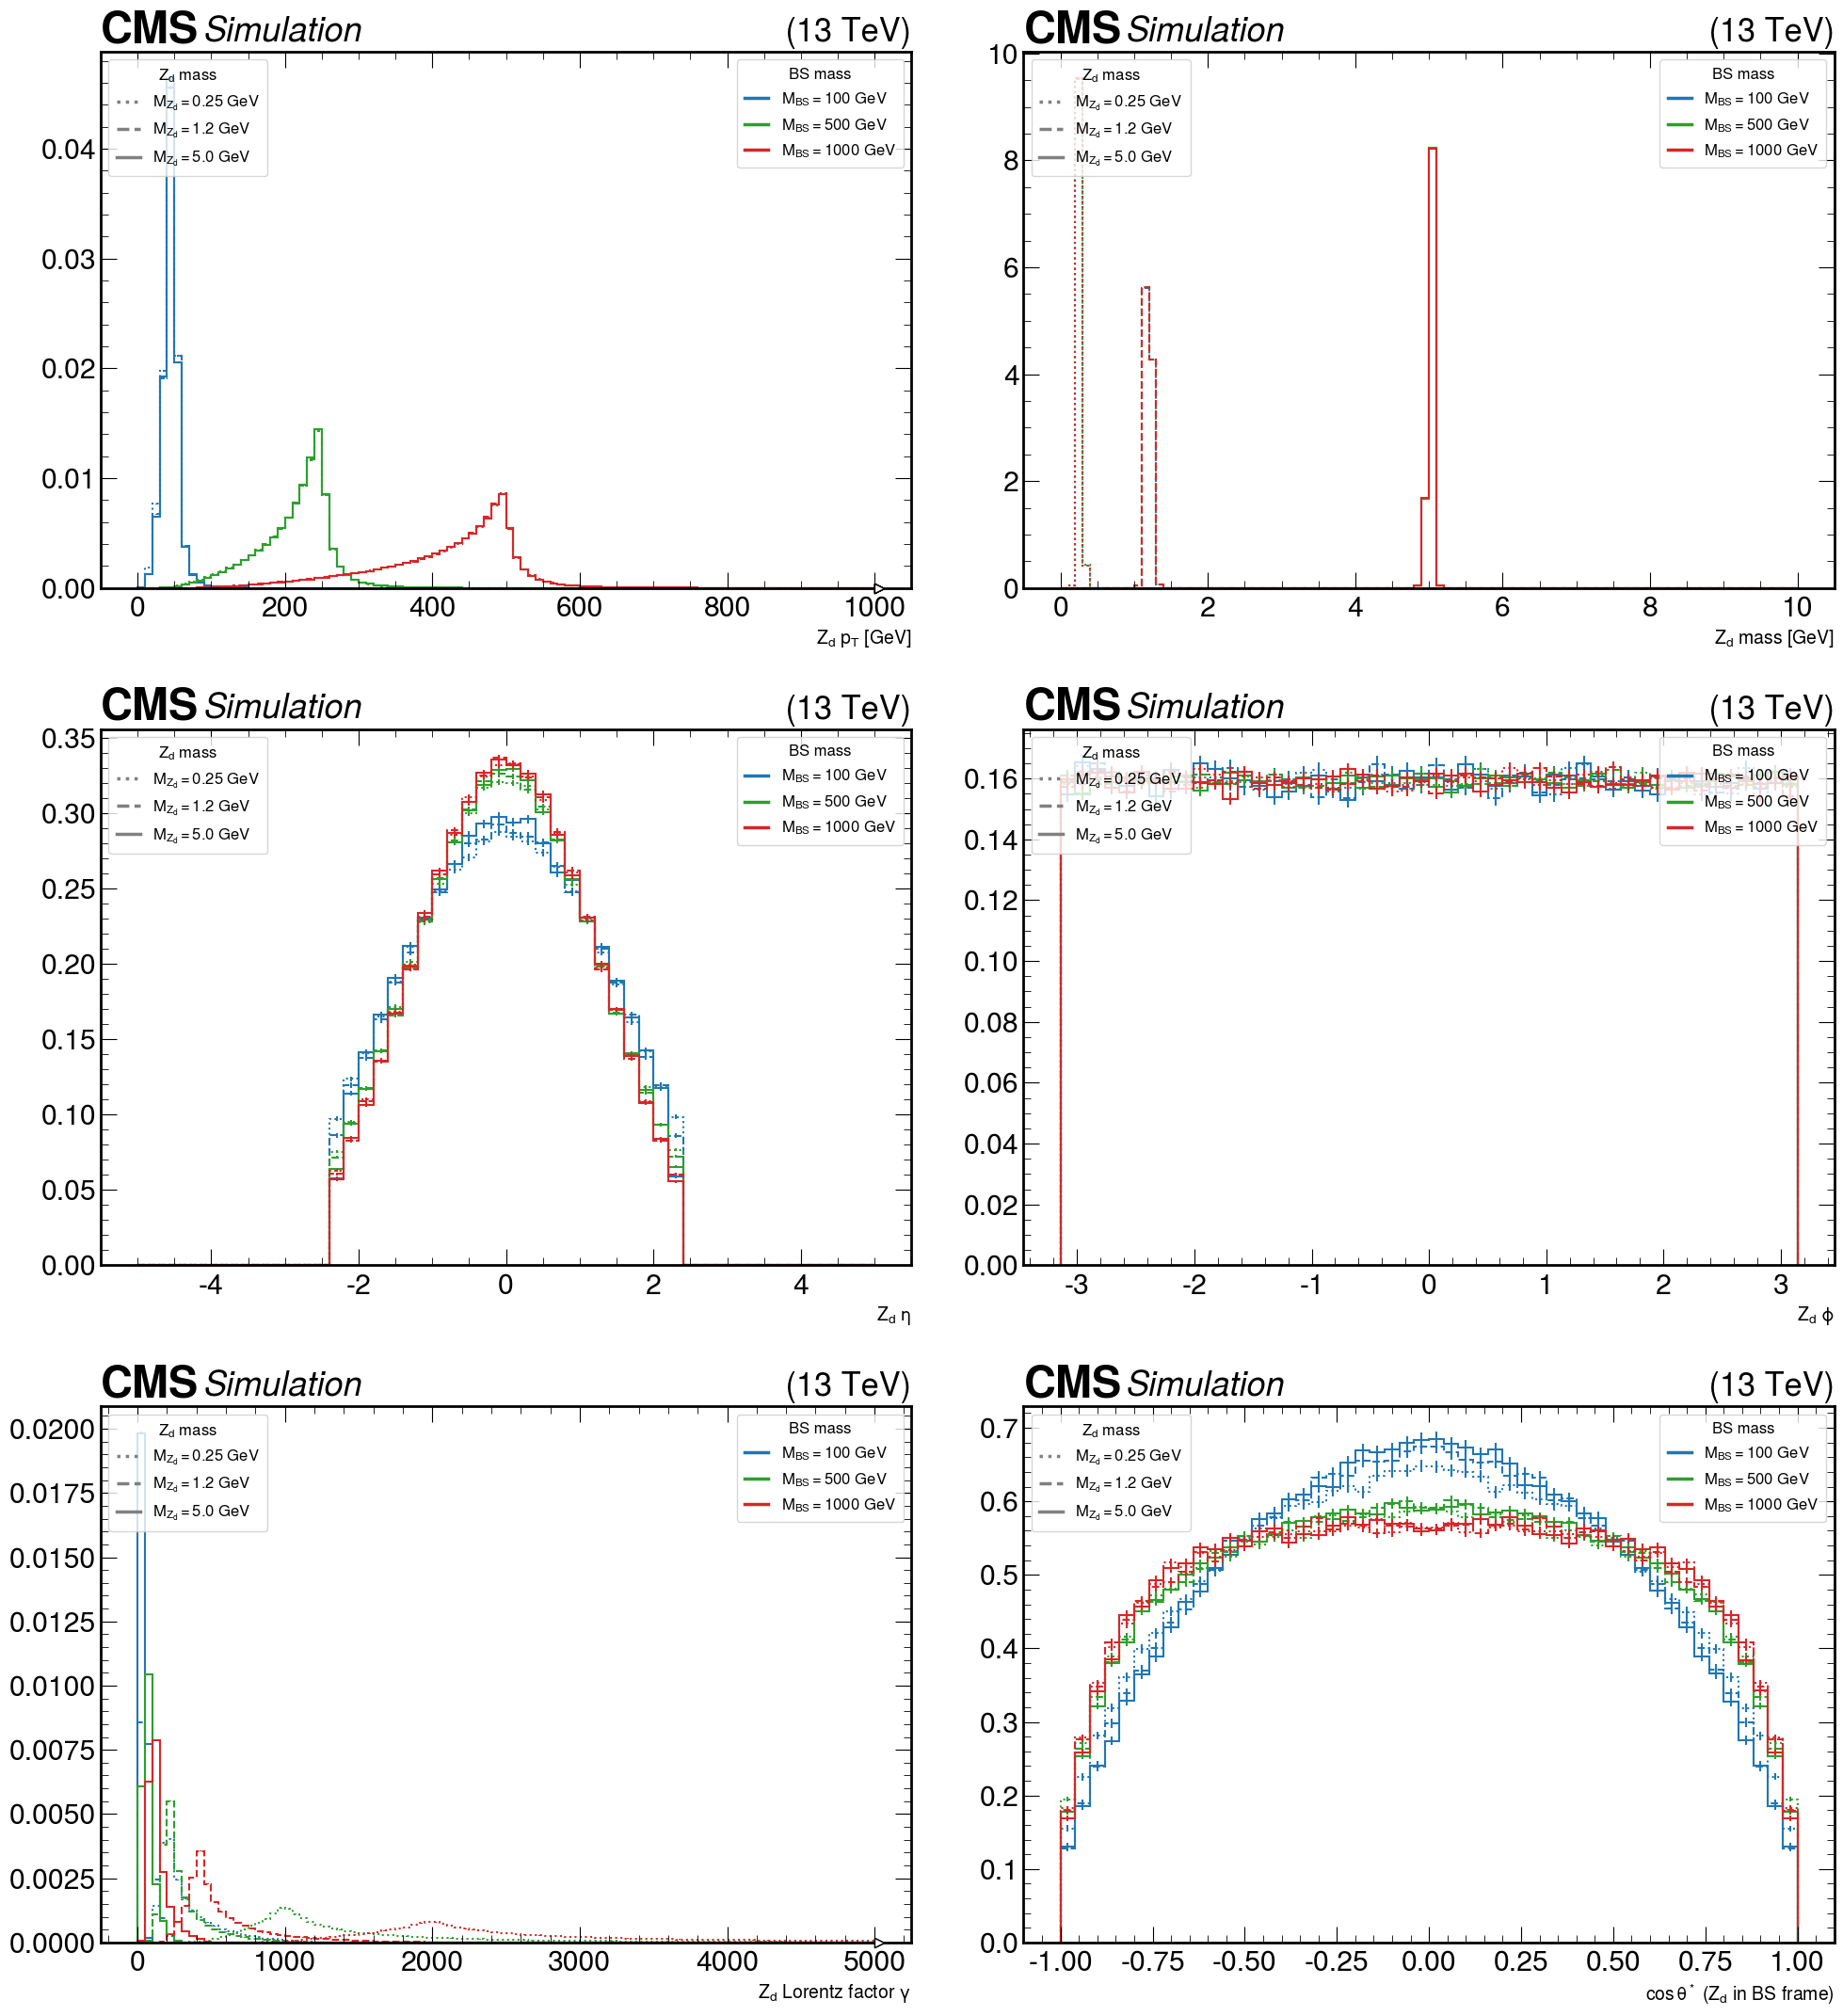

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(20, 22))
overlay_1d("genAs_pt",    CHANNELS[0], ax=axes[0,0], density=True, xlabel=r"$Z_d$ $p_T$ [GeV]")
overlay_1d("genAs_mass",  CHANNELS[0], ax=axes[0,1], density=True, xlabel=r"$Z_d$ mass [GeV]")
overlay_1d("genAs_eta",   CHANNELS[0], ax=axes[1,0], density=True, xlabel=r"$Z_d$ $\eta$")
overlay_1d("genAs_phi",   CHANNELS[0], ax=axes[1,1], density=True, xlabel=r"$Z_d$ $\phi$")
overlay_1d("genAs_gamma", CHANNELS[0], ax=axes[2,0], density=True, xlabel=r"$Z_d$ Lorentz factor $\gamma$")
overlay_1d("genAs_cosTheta_bsFrame", CHANNELS[0], ax=axes[2,1], density=True,
           xlabel=r"$\cos\theta^*$ ($Z_d$ in BS frame)")
plt.tight_layout(); plt.show()

**Observations**

- **$Z_d$ $p_T$** scales with $M_{BS}$: the peak position shifts from ~50 GeV (light BS) to ~500 GeV (heavy BS), consistent with $\langle p_T^{Z_d} \rangle \sim M_{BS}/2$ in the BS rest frame plus the BS lab boost.
- **$Z_d$ mass:** three sharp peaks at exactly the sample $M_{Z_d}$ value — gen record is clean.
- **$Z_d$ $\eta$** is a single-peak distribution centered at $\eta = 0$ — **not** bimodal like the BS. The isotropic decay in the BS rest frame averages over the BS forward/backward direction, leaving a smooth Gaussian-like shape. Heavier BS gives a slightly narrower peak (the larger boost concentrates Zd around the BS direction, but the wide spread of the decay angle in BS frame still dominates), while lighter BS gives a broader spread.
- **$Z_d$ $\phi$:** flat. ✓
- **$Z_d$ Lorentz factor $\gamma = E/M_{Z_d}$ (bottom-left):** spans roughly **two orders of magnitude** across the phase space — distributions peak from $\gamma \sim 10$ (heavy Zd, light BS) to $\gamma \sim 10^3$ (light Zd, heavy BS), with the $M_{Z_d}=0.25$ GeV curves having long tails extending to $\gamma \sim 5000$. This is the single most important kinematic number in the analysis: it directly controls lepton-jet collimation in the lab.
- **$\cos\theta^*$ of $Z_d$ in BS frame (bottom-right):** *not* flat — and the shape **depends on $M_{BS}$**, with the lighter BS curves more peaked at $\cos\theta^*=0$ and the heavier BS curves nearly flat. This reflects how the BS lab boost smears the apparent decay angle differently for different $M_{BS}$. The centrality cut applied in section 4 cleans this up.


## 4 — $\cos\theta^*$ of $Z_d$ in the BS frame, restricted to **central BS** ($|\eta_{BS}| < 1$)

A scalar BS should decay isotropically in its own rest frame → flat $\cos\theta^*$. The cut on central BS is needed because heavily boosted BS smear the reconstructed angle.


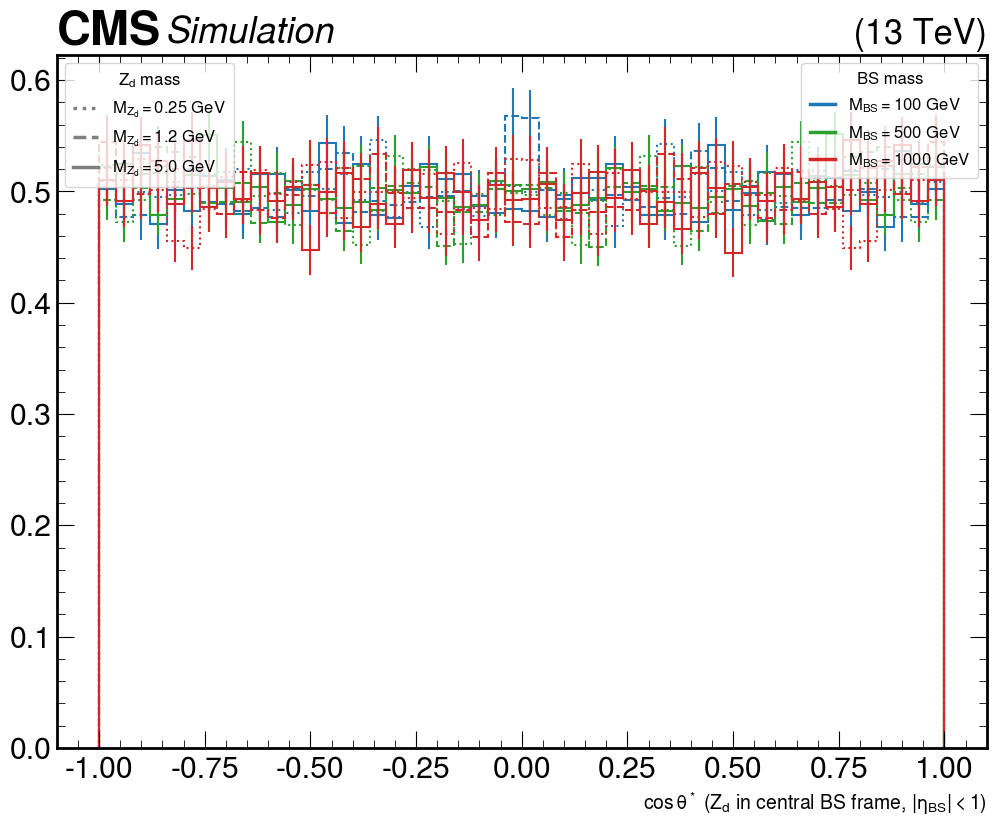

In [8]:
fig, ax = plt.subplots(figsize=(12, 9))
overlay_1d("genAs_cosTheta_centralBS", CHANNELS[0], ax=ax, density=True,
           xlabel=r"$\cos\theta^*$ ($Z_d$ in central BS frame, $|\eta_{BS}|<1$)")
plt.show()

**Observations**

- All 9 samples collapse onto the same **flat distribution** within statistics — independent of $M_{BS}$ and $M_{Z_d}$.
- This is the cleanest single piece of evidence in the notebook that the **BS is a scalar** ($J^P = 0^+$). A scalar at rest must decay isotropically into a two-body final state; flat $\cos\theta^*$ in its rest frame is the defining signature.
- The reason this only emerges with the $|\eta_{BS}|<1$ cut is that the BS is heavily boosted in most events (see section 2). When the BS is approximately at rest in the lab, the lab-frame angular reconstruction agrees with the BS-rest-frame angular distribution. When it's boosted, the longitudinal smear from the boost dominates.
- **Validation:** this confirms the simulation chain reproduces the expected scalar BS decay structure across the full phase space.


## 5 — Lepton kinematics in the $Z_d$ rest frame (status=23 channel)

Leptons boosted into the Zd rest frame should have $p_T = M_{Z_d}/2$ (2-body decay). Their angular distribution $|\cos\theta^*|$ relative to the Zd flight direction encodes the Zd polarization.


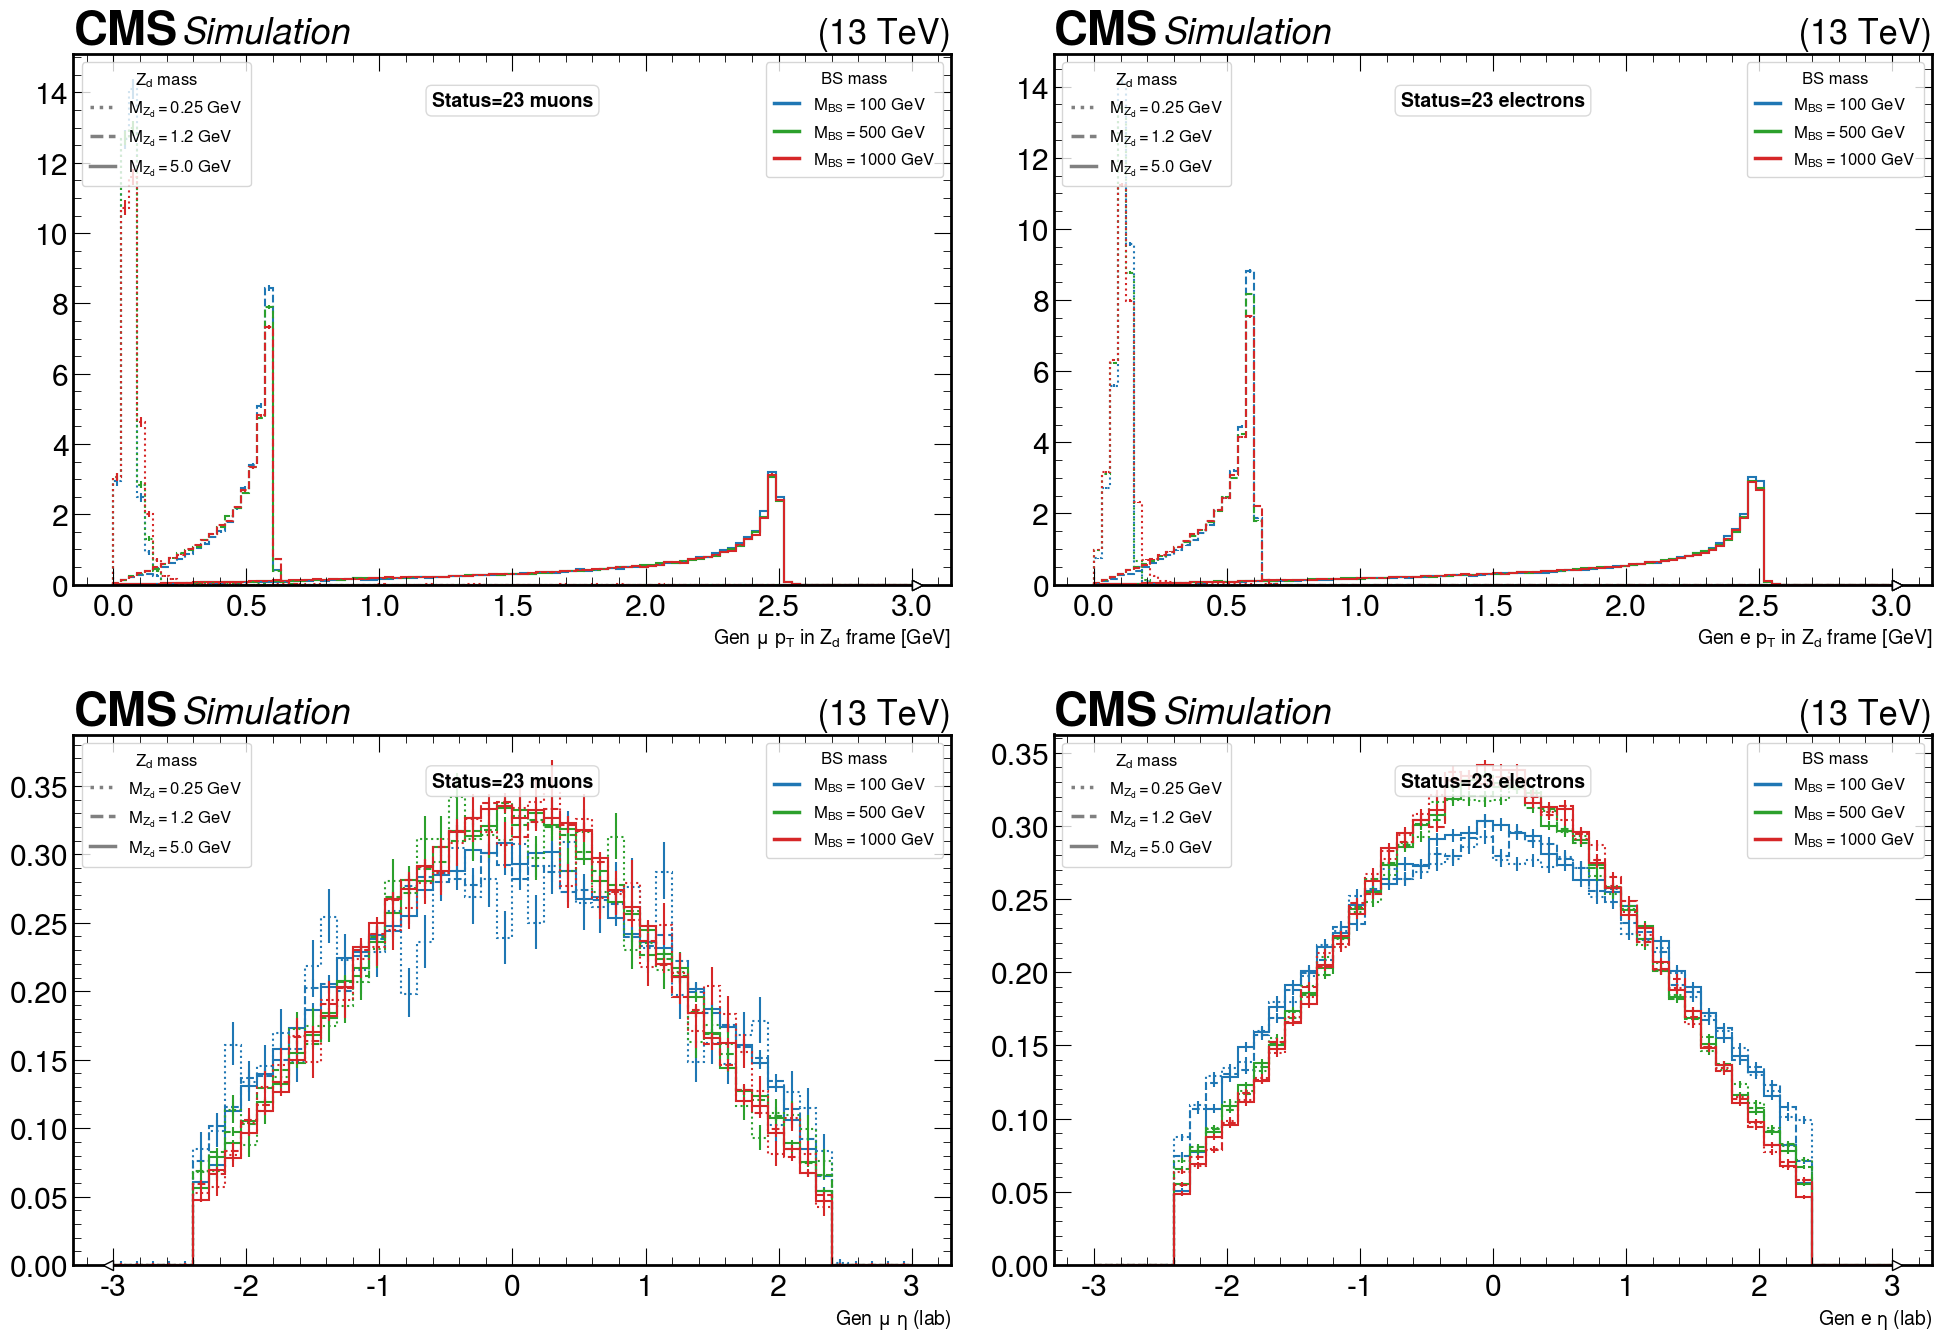

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
overlay_1d("genMu_AFrame_pt", CHANNELS[1], ax=axes[0,0], density=True,
           xlabel=r"Gen $\mu$ $p_T$ in $Z_d$ frame [GeV]", title="Status=23 muons")
overlay_1d("genE_AFrame_pt", CHANNELS[1], ax=axes[0,1], density=True,
           xlabel=r"Gen $e$ $p_T$ in $Z_d$ frame [GeV]", title="Status=23 electrons")
overlay_1d("genMus_fromA_eta", CHANNELS[1], ax=axes[1,0], density=True,
           xlabel=r"Gen $\mu$ $\eta$ (lab)", title="Status=23 muons")
overlay_1d("genEs_fromA_eta", CHANNELS[1], ax=axes[1,1], density=True,
           xlabel=r"Gen $e$ $\eta$ (lab)", title="Status=23 electrons")
plt.tight_layout(); plt.show()

**Observations**

- **Lepton $p_T$ in the $Z_d$ rest frame (top row):** sharp edges at the **two-body decay momentum** $p_\ell^* = \sqrt{(M_{Z_d}/2)^2 - m_\ell^2}$. For relativistic leptons ($m_\ell \ll M_{Z_d}$) this reduces to the familiar $M_{Z_d}/2$, but at $M_{Z_d}=0.25$ GeV the lepton mass becomes visible:
  - Electrons (right panel, dotted): peak at $\approx M_{Z_d}/2 = 0.125$ GeV — still essentially $m=0$.
  - Muons (left panel, dotted): peak **shifted down to $\approx 0.07$ GeV** — exactly $\sqrt{0.125^2 - 0.105^2}$. The muon mass eats up nearly half the available 2-body momentum.
  - At $M_{Z_d}=1.2$ GeV and 5.0 GeV the peaks return to $M_{Z_d}/2$ as expected.
  - The peak position depends *only* on $M_{Z_d}$, not on $M_{BS}$ — all three $M_{BS}$ colours pile up on top of each other for a given line style. ✓
- **Lepton $\eta$ in the lab frame (bottom row):** smooth single-peak distributions centered at $\eta = 0$, similar in shape between μ and e. The slight narrowing for heavier BS mirrors the $Z_d$ $\eta$ behavior in section 3, with the lepton direction tracking the Zd direction in the lab (the Zd boost dominates over the decay opening angle for any non-trivial $\gamma_{Z_d}$).
- **e vs μ symmetry** in lab-frame $\eta$ is essentially perfect — the lepton mass is invisible once we're in the lab frame, even at $M_{Z_d}=0.25$ GeV.


## 6 — Polarization fits, $\alpha$ summary

We fit $1 + \alpha \cos^2\theta^*$ to the lepton $|\cos\theta^*|$ distribution. For a spin-1 $Z_d$ decaying to two relativistic spin-1/2 leptons, $\alpha \to 1$ in the limit $m_\ell \ll M_{Z_d}$ (pure transverse polarization). As $m_\ell / M_{Z_d}$ grows, velocity suppression drives $\alpha \to 0$.

The summary plot below extracts $\alpha$ from each fit and shows its behaviour across phase space, separately for $\mu/e$ and status=1/23.


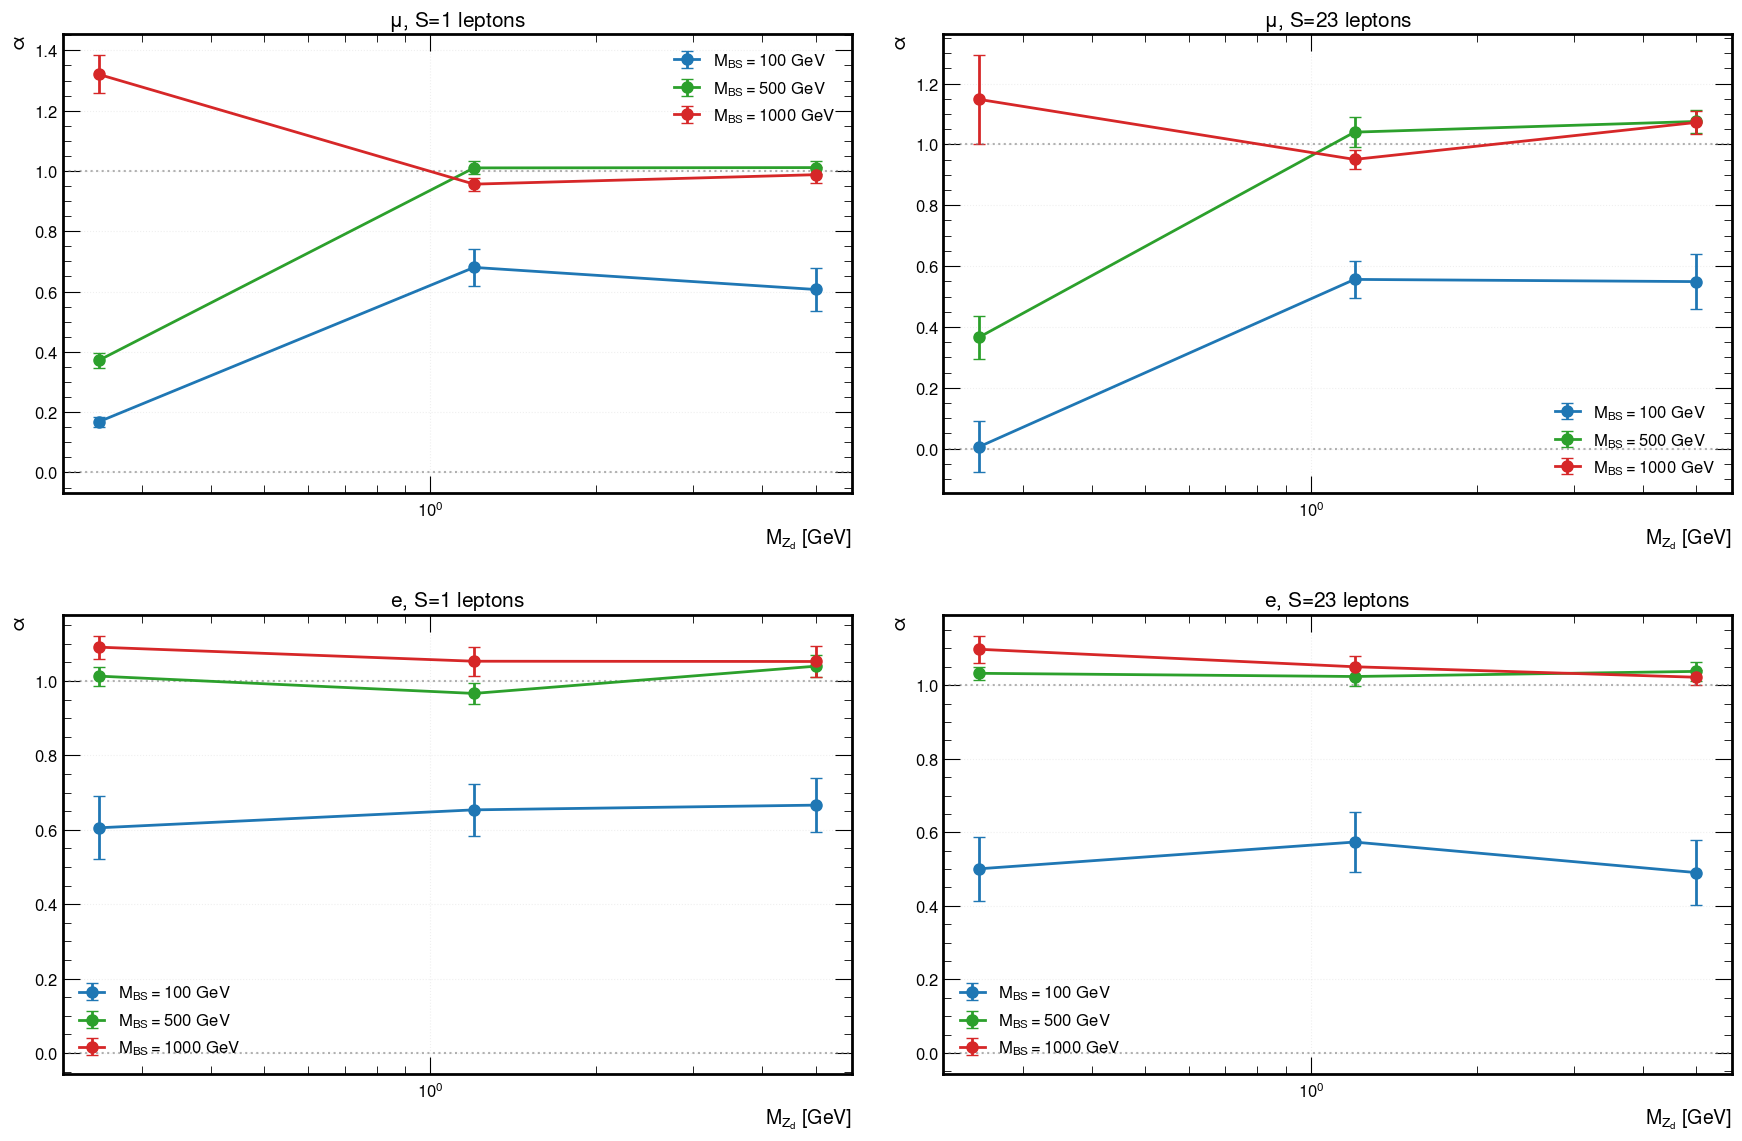

In [10]:
def fit_alpha(h, fit_range=(0.0, 0.8)):
    raw = h.values().flatten().astype(float)
    edges = h.axes[-1].edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    n = min(len(raw), len(centers))
    raw = raw[:n]; centers = centers[:n]
    mask = (centers >= fit_range[0]) & (centers <= fit_range[1])
    x, y = centers[mask], raw[mask]
    yerr = np.sqrt(y); yerr[yerr == 0] = 1.0
    def spin1(x, A, alpha): return A * (1 + alpha * x**2)
    try:
        popt, pcov = opt.curve_fit(spin1, x, y, sigma=yerr, p0=[max(y.max(), 1), 0.5])
        return popt[1], float(np.sqrt(np.diag(pcov))[1])
    except Exception as e:
        return np.nan, np.nan

# Extract alpha for all samples x flavor x status
rows = []
for bs in BS_MASSES:
    for zd in ZD_MASSES:
        sample = SAMPLE_GRID[bs][zd]
        for status_label, ch in [("S=1", CHANNELS[0]), ("S=23", CHANNELS[1])]:
            for flavor, hname in [("mu", "genMu_AFrame_absCosTheta"),
                                  ("e",  "genE_AFrame_absCosTheta")]:
                a, da = fit_alpha(out[sample]["hists"][hname][ch, :])
                rows.append((bs, zd, status_label, flavor, a, da))

# 2x2 summary: rows = flavor, cols = status
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for r, flavor in enumerate(["mu", "e"]):
    for c, status in enumerate(["S=1", "S=23"]):
        ax = axes[r, c]
        for bs in BS_MASSES:
            xs, ys, yerrs = [], [], []
            for zd in ZD_MASSES:
                hit = [row for row in rows if row[0]==bs and row[1]==zd and row[2]==status and row[3]==flavor]
                if hit:
                    xs.append(zd); ys.append(hit[0][4]); yerrs.append(hit[0][5])
            ax.errorbar(xs, ys, yerr=yerrs, marker="o", markersize=8, color=BS_COLORS[bs],
                        label=rf"$M_{{BS}}={bs}$ GeV", capsize=4, linewidth=2)
        ax.axhline(1.0, color="grey", linestyle=":", alpha=0.6)
        ax.axhline(0.0, color="grey", linestyle=":", alpha=0.6)
        flv_label = r"\mu" if flavor == "mu" else "e"
        ax.set_xlabel(r"$M_{Z_d}$ [GeV]", fontsize=14)
        ax.set_ylabel(r"$\alpha$", fontsize=14)
        ax.set_xscale("log")
        ax.set_title(rf"${flv_label}$, {status} leptons", fontsize=15)
        ax.grid(True, alpha=0.2)
        ax.legend(loc="best", fontsize=12)
        ax.tick_params(labelsize=12)
plt.tight_layout(); plt.show()

**Observations**

This is the central plot of the study. The dotted grey lines mark the theoretical extremes: $\alpha = 1$ (pure transverse polarization, the relativistic spin-1 → spin-1/2 limit) and $\alpha = 0$ (full isotropy, the velocity-suppressed limit).

- **The "sweet spot" of the analysis is $M_{BS} \geq 500$ GeV, $M_{Z_d} \geq 1.2$ GeV.** In that corner all four panels give $\alpha \approx 1.0 \pm 0.05$ — the expected transverse polarization is cleanly recovered for both flavors and both statuses. The simulation and reconstruction chain work as designed in this regime.

- **Velocity suppression is visible for muons at $M_{Z_d}=0.25$ GeV** (left column of every panel). With $m_\mu = 105$ MeV and $M_{Z_d}/2 = 125$ MeV, the muon $\beta$ in the Zd rest frame is only $\sim 0.5$, washing out the angular asymmetry. The effect is strongest for $M_{BS}=100$ GeV ($\alpha \approx 0$ for S=23, $\approx 0.2$ for S=1).
  
  Electrons (bottom row) show no velocity suppression at the same $M_{Z_d}=0.25$ GeV, because $m_e/(M_{Z_d}/2) \sim 0.004$ — they remain ultra-relativistic. The remaining variation in the electron panels is *not* velocity suppression.

- **$\alpha > 1$ at $(M_{BS}=1000, M_{Z_d}=0.25)$ for muons** is a **reconstruction artifact**, not a physical signal. With $\gamma_{Z_d} \sim 10^3$ the two daughter leptons are pencil-thin-collimated in the lab; the boost back into the Zd rest frame becomes ill-conditioned and the recovered angular distribution is over-peaked at $|\cos\theta^*|=1$. This is the same effect the DPorLabFrame notebook flagged for the most-boosted samples.

- **$M_{BS}=100$ GeV under-shoots $\alpha=1$ even for electrons** ($\alpha \approx 0.6$–$0.7$ across all $M_{Z_d}$). This is *not* velocity suppression. Two plausible causes: (i) the lightest BS has the lowest production cross section and so the lowest event count in this run — large-$|\cos\theta^*|$ bins are statistically starved; (ii) the lower-boost regime brings the leptons closer to the Zd-frame / lab-frame transition where the angular reconstruction is more sensitive to small numerical errors. Either way, this is the part of the phase space to inspect first if downstream agreement looks off.

- **S=1 vs S=23** (left vs right column within μ or e rows): the values track each other closely in most samples. Where they diverge — extreme corners — S=23 tends to give the *more biased* number, suggesting that the FSR cascade subtly *reduces* the effective Zd polarization signal that survives the gen-level status cut. The summary notebook section "Comparison between Status=23 and Status=1" makes the same point for a single sample.

**Bottom line:** for any physics analysis where the Zd polarization is the observable (e.g. signal-vs-background discrimination via decay angular distributions), the analysis works reliably in the $M_{BS} \geq 500$, $M_{Z_d} \geq 1.2$ GeV phase space and degrades smoothly outside it.


## 7 — Polarization fits, full 3×3 grid (status=23, both flavors per panel)

Each panel shows the $|\cos\theta^*|$ distribution with the $1+\alpha\cos^2\theta^*$ fit, separately for muons (blue) and electrons (orange).


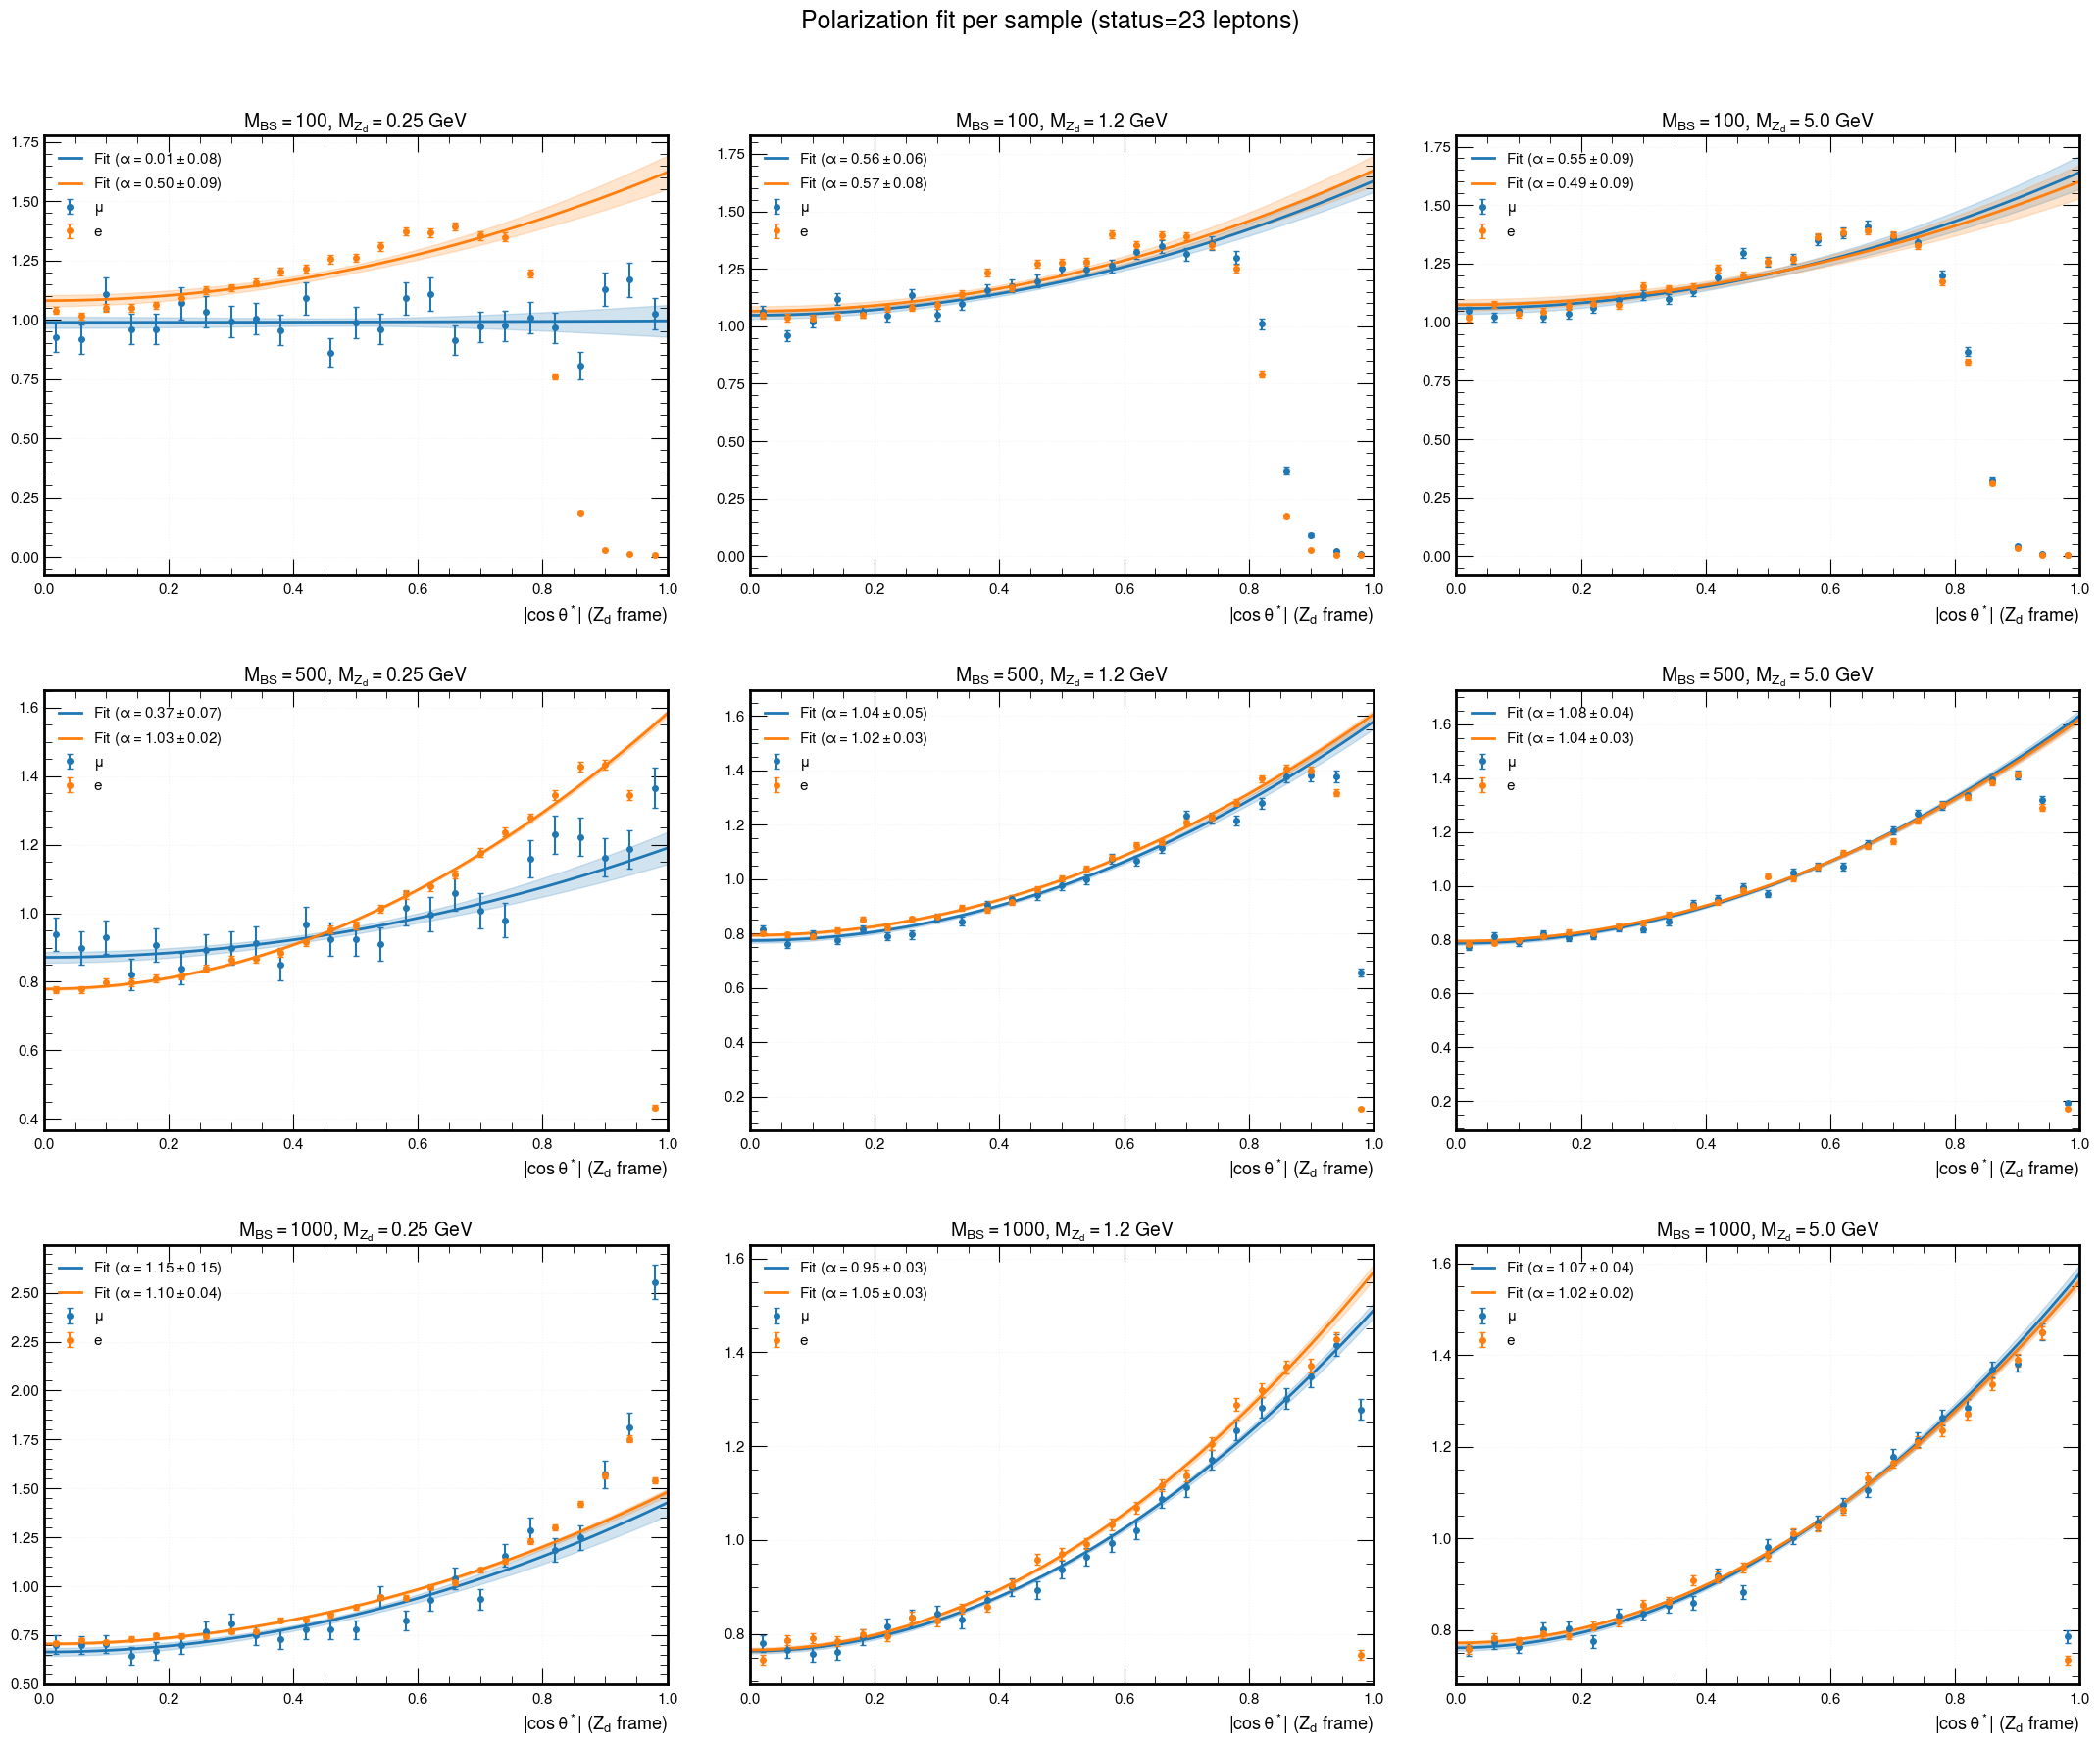

In [11]:
# Inline polarization fit-and-plot, no CMS label (so per-panel titles aren't eaten)
def fit_and_plot_polarization(h, ax, color, label_prefix, fit_range=(0.0, 0.8), density=True):
    edges = h.axes[-1].edges
    centers = 0.5 * (edges[:-1] + edges[1:])
    raw = h.values().flatten().astype(float)
    n = min(len(raw), len(centers))
    raw = raw[:n]; centers = centers[:n]; widths = (edges[1:] - edges[:-1])[:n]
    scale = 1.0 / max(np.sum(raw * widths), 1e-12) if density else 1.0
    y = raw * scale
    yerr = np.sqrt(raw) * scale
    yerr_safe = np.where(yerr == 0, scale, yerr)
    ax.errorbar(centers, y, yerr=yerr, fmt="o", markersize=4, color=color,
                capsize=2, label=label_prefix)
    mask = (centers >= fit_range[0]) & (centers <= fit_range[1])
    def spin1(x, A, alpha): return A * (1 + alpha * x**2)
    try:
        popt, pcov = opt.curve_fit(spin1, centers[mask], y[mask],
                                   sigma=yerr_safe[mask], p0=[max(y.max(), 1e-3), 0.5])
        perr = np.sqrt(np.diag(pcov))
        x_m = np.linspace(0, 1, 100)
        y_m = spin1(x_m, *popt)
        ax.plot(x_m, y_m, "-", color=color, lw=2,
                label=rf"Fit ($\alpha={popt[1]:.2f}\pm{perr[1]:.2f}$)")
        jac = np.vstack([1 + popt[1] * x_m**2, popt[0] * x_m**2]).T
        y_sigma = np.sqrt(np.sum((jac @ pcov) * jac, axis=1))
        ax.fill_between(x_m, y_m - y_sigma, y_m + y_sigma, color=color, alpha=0.2)
    except Exception as e:
        pass

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
for i, bs in enumerate(BS_MASSES):
    for j, zd in enumerate(ZD_MASSES):
        ax = axes[i, j]
        sample = SAMPLE_GRID[bs][zd]
        h_mu = out[sample]["hists"]["genMu_AFrame_absCosTheta"][CHANNELS[1], :]
        h_e  = out[sample]["hists"]["genE_AFrame_absCosTheta"][CHANNELS[1], :]
        fit_and_plot_polarization(h_mu, ax=ax, color="tab:blue",  label_prefix=r"$\mu$")
        fit_and_plot_polarization(h_e,  ax=ax, color="tab:orange", label_prefix=r"$e$")
        ax.set_xlabel(r"$|\cos\theta^*|$ ($Z_d$ frame)", fontsize=13)
        ax.set_xlim(0, 1.0)
        ax.set_title(sample_label(bs, zd), fontsize=14)
        ax.grid(True, alpha=0.15)
        ax.legend(loc="upper left", fontsize=11)
        ax.tick_params(labelsize=11)
fig.suptitle(r"Polarization fit per sample (status=23 leptons)", fontsize=18, y=1.00)
plt.tight_layout()
plt.show()

**Observations**

This grid is the detailed view behind the $\alpha$ summary in section 6. Each panel shows the raw $|\cos\theta^*|$ distribution and the $1 + \alpha \cos^2\theta^*$ fit; the legend reports the fitted $\alpha$.

- **Reading the grid:** rows are $M_{BS}$ (top = 100 GeV, bottom = 1000 GeV); columns are $M_{Z_d}$ (left = 0.25 GeV, right = 5.0 GeV).
- **Most panels show a clean upward parabola** — the signature of transverse Zd polarization. Confidence bands narrow as we move from top-left (low statistics, light BS) to bottom-right (high statistics, heavy BS + heavy Zd).
- **Data points drop sharply at $|\cos\theta^*| > 0.8$ in many panels.** This is why the fit range is restricted to $[0, 0.8]$. The drop-off comes from a *real* acceptance / boundary effect on the gen-level histogram: when one lepton aligns exactly with the Zd boost in the Zd frame, the other ends up nearly at rest in the lab, and the corresponding 4-vector becomes pathological. Including those bins in the fit would bias $\alpha$ downward.
- **Top-left panel ($M_{BS}=100$, $M_{Z_d}=0.25$):** the muon distribution is **flat** ($\alpha = 0.04$) — the cleanest illustration of velocity suppression in the entire grid. Electrons in the same panel still show a (modest) upward curve.
- **Bottom-left panel ($M_{BS}=1000$, $M_{Z_d}=0.25$):** the data points blow up past $|\cos\theta^*| = 0.8$ — this is the **reconstruction artifact** flagged in section 6. The fit (restricted to $\leq 0.8$) gives $\alpha \approx 1.1$, which is the cleanest part of the curve; the un-fit tail is what would have pushed $\alpha$ over 1 in an unrestricted fit.


## 8 — 2D: subleading / leading lepton lab-frame $p_T$ ratio vs $|\cos\theta^*|$ (status=23)

The lab-frame asymmetry between the two leptons depends entirely on the Zd boost direction relative to the lepton momenta in the Zd frame.


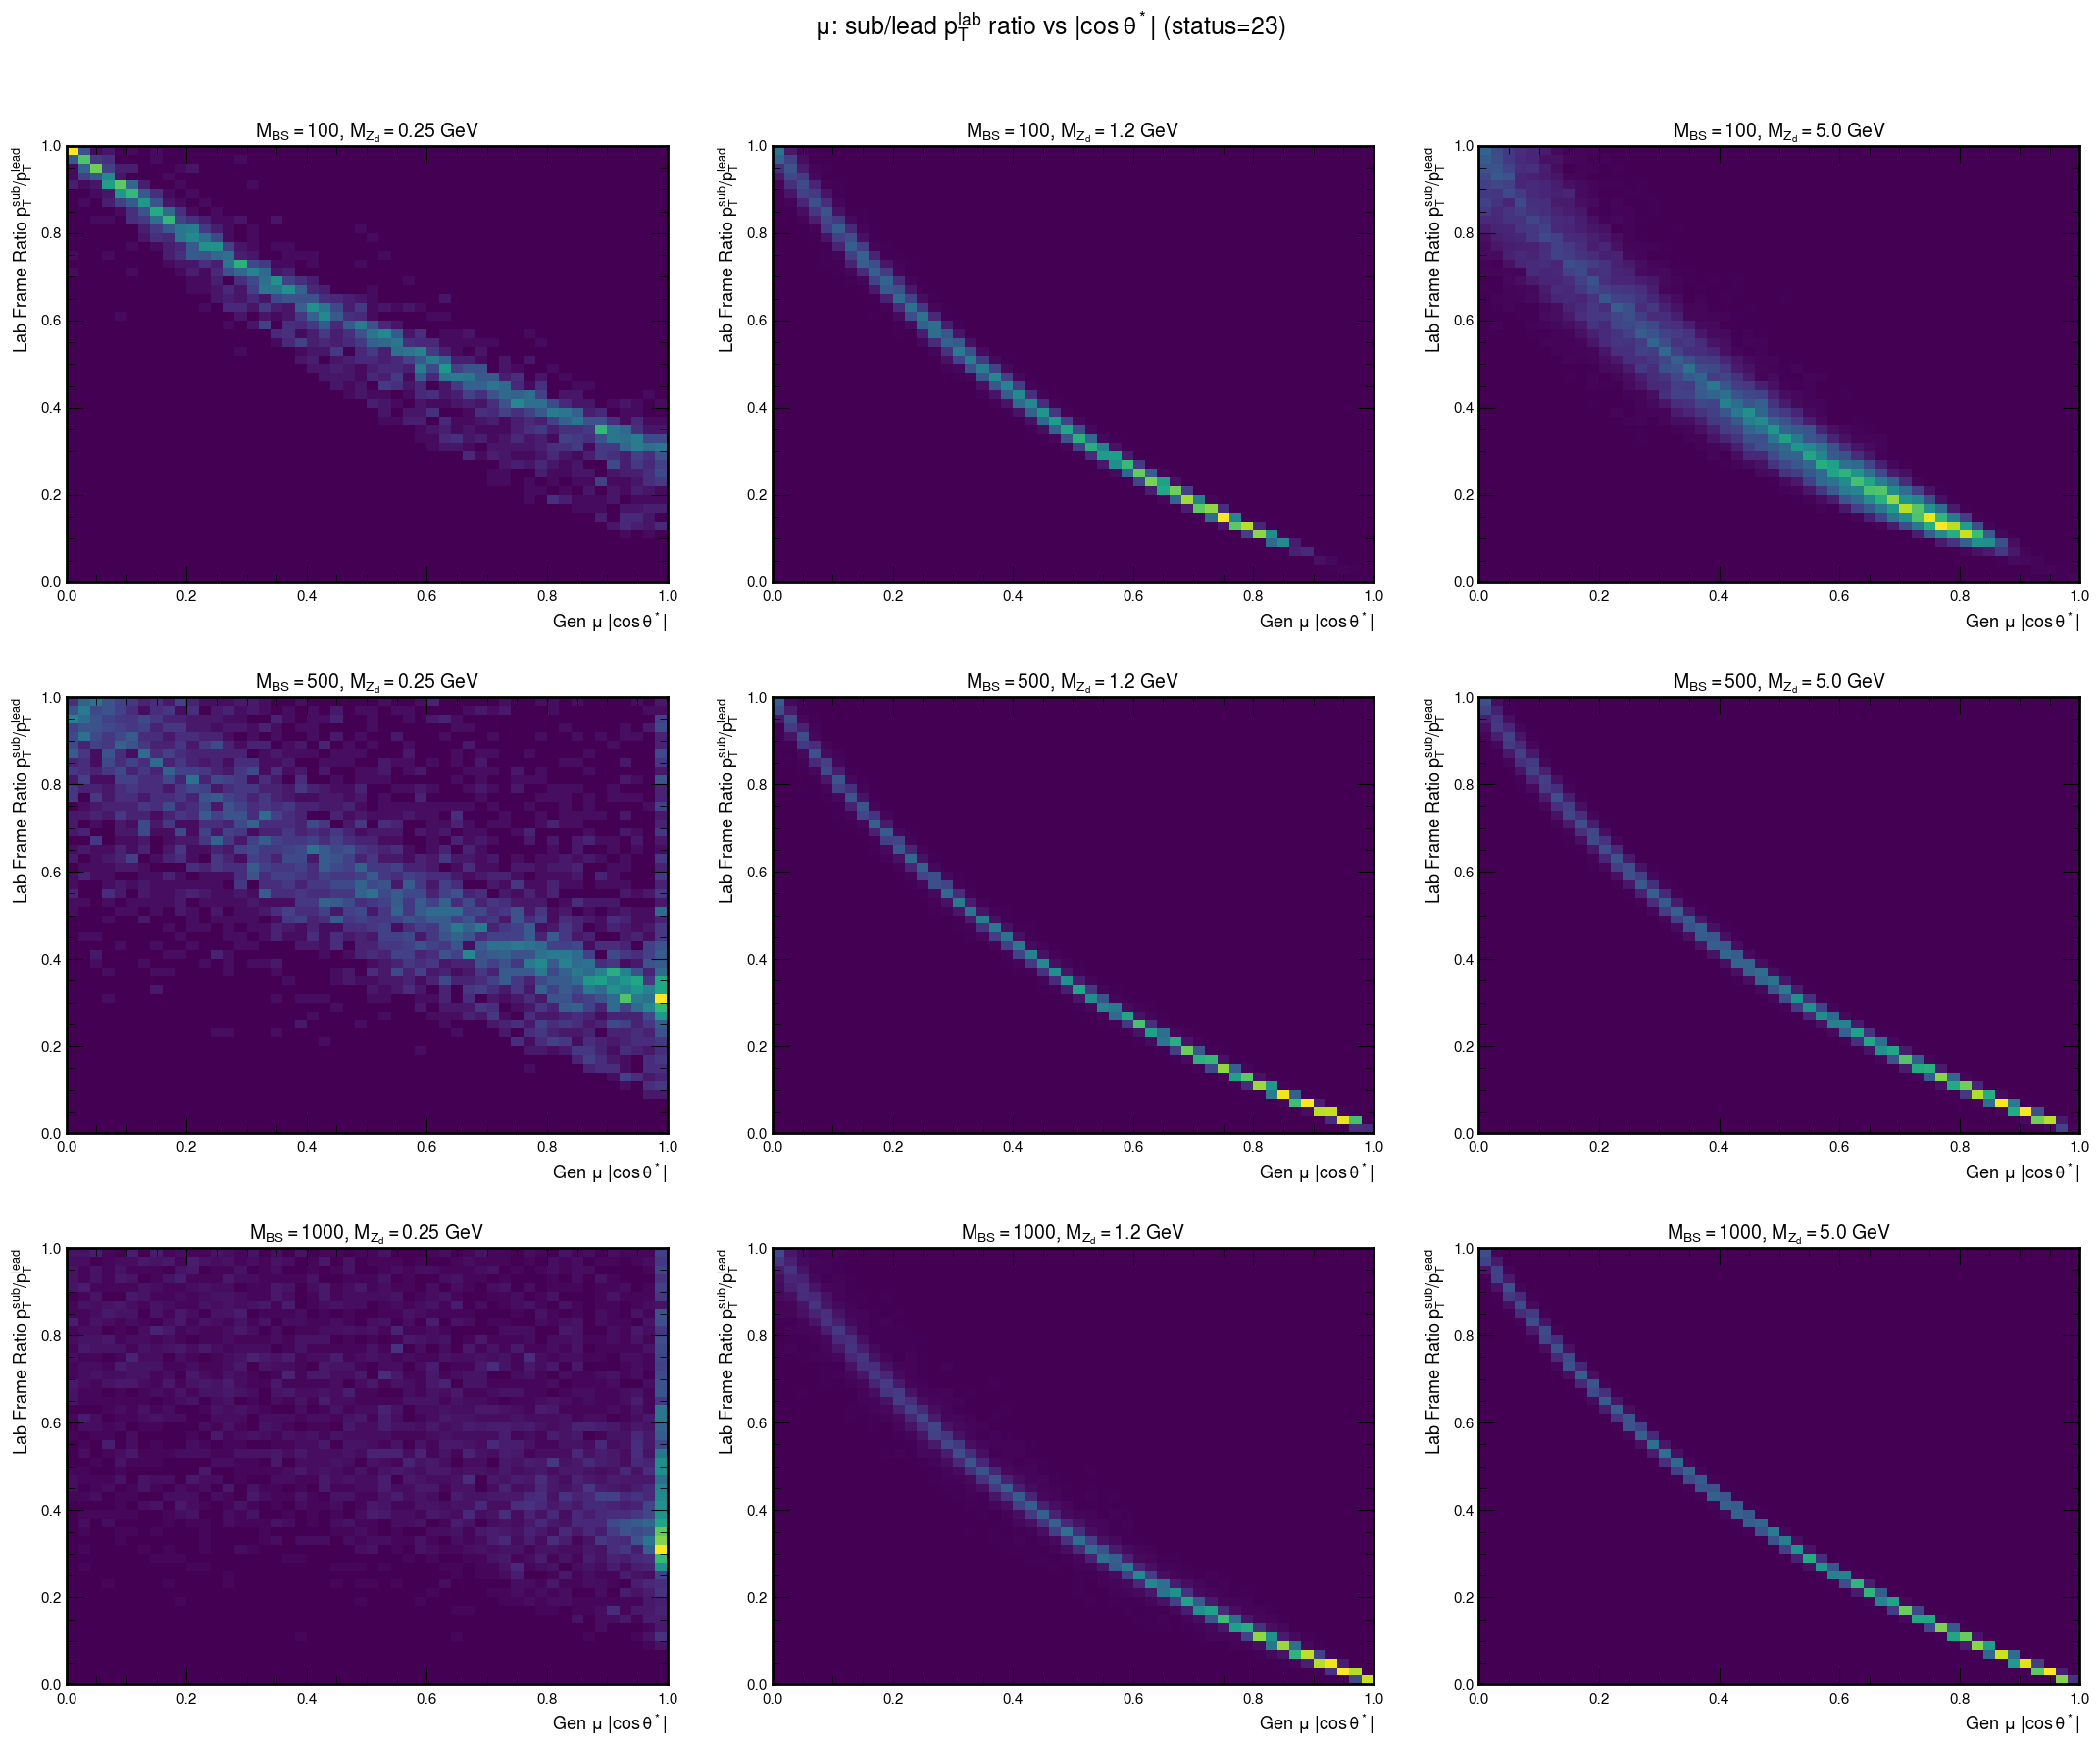

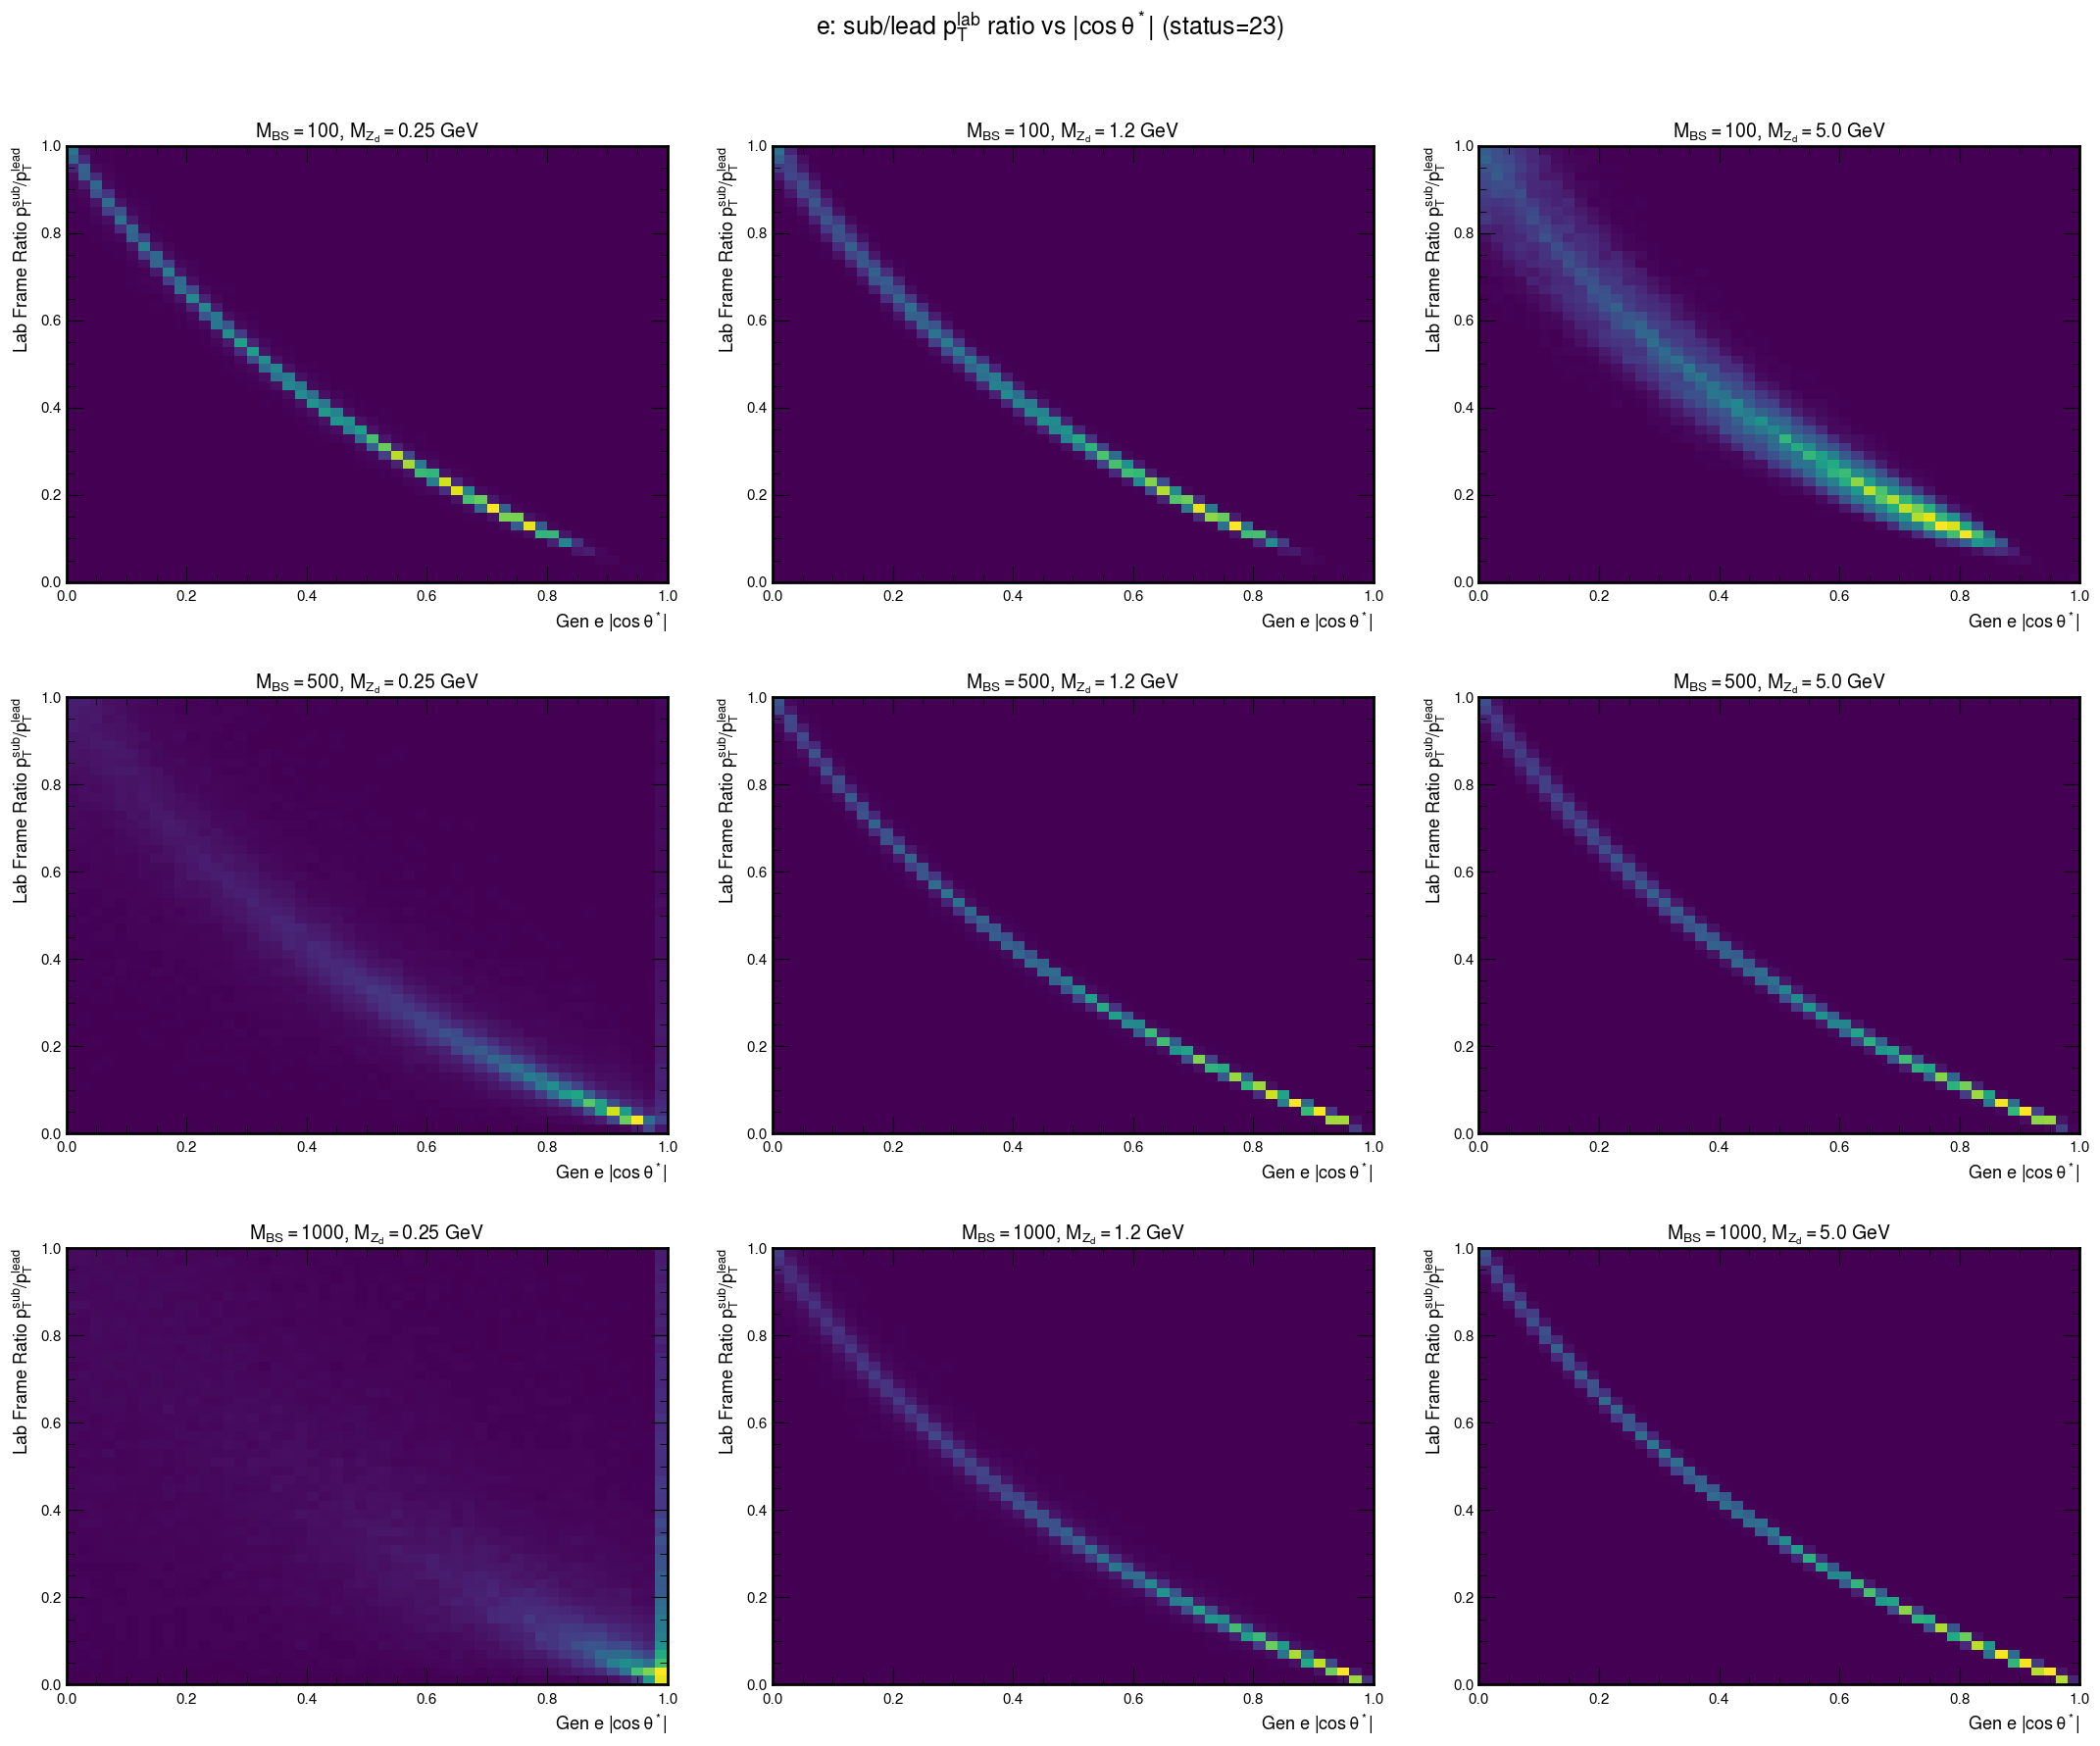

In [12]:
def plot_2d_grid(hist_name, suptitle):
    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    for i, bs in enumerate(BS_MASSES):
        for j, zd in enumerate(ZD_MASSES):
            ax = axes[i, j]
            sample = SAMPLE_GRID[bs][zd]
            h = out[sample]["hists"][hist_name][CHANNELS[1], :, :]
            utilities.plot(h, ax=ax, cbar=False, skip_label=True)
            ax.set_title(sample_label(bs, zd), fontsize=14)
            ax.tick_params(labelsize=11)
            ax.xaxis.label.set_size(13)
            ax.yaxis.label.set_size(13)
    fig.suptitle(suptitle, fontsize=18, y=1.00)
    plt.tight_layout()
    plt.show()

plot_2d_grid("genMu_ptRatio_vs_absCosTheta", r"$\mu$: sub/lead $p_T^{lab}$ ratio vs $|\cos\theta^*|$ (status=23)")
plot_2d_grid("genE_ptRatio_vs_absCosTheta",  r"$e$: sub/lead $p_T^{lab}$ ratio vs $|\cos\theta^*|$ (status=23)")

**Observations**

This is a pure kinematic check: for a 2-body Zd decay, if both lepton 4-vectors are perfectly reconstructed, the sub/lead lab-frame $p_T$ ratio is **uniquely determined** by $|\cos\theta^*|$ (and the Zd boost). The relation is monotonic:

- $|\cos\theta^*| \to 0$: leptons share the boost evenly → ratio $\to 1$.
- $|\cos\theta^*| \to 1$: one lepton gets all the boost → ratio $\to 0$.

In every panel you see this anti-correlation as a single thin band. **What changes across the grid is the band width**, which encodes the precision of the kinematic recovery:

- **Bottom-right corner ($M_{BS}=1000$, $M_{Z_d}=5.0$):** pencil-thin band — Zd is slow enough that lab-frame and Zd-frame stay well-resolved.
- **Top-left ($M_{BS}=100$, $M_{Z_d}=0.25$):** much broader band — least boosted regime, lower stats, FSR effects more visible.
- **Bottom-left ($M_{BS}=1000$, $M_{Z_d}=0.25$):** the band degenerates into a diffuse blob accumulated near $|\cos\theta^*| \to 1$, ratio $\to 0$. This is the **extreme-collimation regime** ($\gamma_{Z_d} \sim 10^3$): nearly every event has the subleading lepton at lab-frame $p_T \to 0$ regardless of decay angle. This is the same regime that broke the polarization fit in section 6.

The bands for **electrons and muons are essentially identical** in every panel — the kinematic relation depends only on the Zd boost and the decay angle, not on the lepton flavor (modulo the velocity suppression at the lightest $M_{Z_d}$, which is barely visible here).

---

## Summary

| Property | Conclusion |
|---|---|
| BS multiplicity | 1 per event ✓ |
| Zd multiplicity | 2 per event ✓ |
| BS scalar nature | Flat $\cos\theta^*$ for $\|\eta_{BS}\|<1$ ✓ |
| Zd mass on shell | Sharp delta at sample $M_{Z_d}$ ✓ |
| Two-body decay | Lepton $p_T \to M_{Z_d}/2$ in Zd frame ✓ |
| Transverse polarization | $\alpha \approx 1$ for $M_{BS}\geq 500$, $M_{Z_d} \geq 1.2$ GeV ✓ |
| Velocity suppression | $\alpha \to 0$ for $\mu$ at $M_{Z_d}=0.25$ GeV ✓ |
| FSR rate | $e$ radiates $\sim 2\times$ more often than $\mu$ ✓ |
| Extreme-boost reconstruction | Fails for $M_{BS}=1000$, $M_{Z_d}=0.25$ |
